In [1]:
import pandas as pd
import numpy as np
import os
from glob import glob
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as patches
import matplotlib.patches as mpatches
from warnings import filterwarnings
import matplotlib.lines as mlines
import scipy

filterwarnings('ignore')

### functions

In [2]:
def collect_loso_results(result_dir, category_sources, category_formats, category_names_allformats_merged, region_group, noiseceiling=False):
    loso_results = pd.DataFrame()
    for source in category_sources:
        for _ , format_type in enumerate(category_formats):
            if noiseceiling:
                performance_df = pd.read_csv(os.path.join(result_dir, source, format_type, f'loso_performance_noiseceiling_{region_group}.csv'))
            else:
                performance_df = pd.read_csv(os.path.join(result_dir, source, format_type, f'loso_performance_{region_group}.csv'))
            performance_df['source'] = source
            performance_df['format'] = format_type
            loso_results = pd.concat([loso_results, performance_df])
    return pd.melt(loso_results, id_vars=loso_results.columns[~loso_results.columns.isin(category_names_allformats_merged)], value_vars=category_names_allformats_merged, var_name='category', value_name='corr')


def plot_subjectConnected_performance_scatter(performance_all, title, legend_title, outer_x_order, outer_x_labels, 
                                              outer_x_column_name, inner_x_order, inner_x_labels, inner_x_column_name, 
                                              y_column_name, inner_x_colors, subject_column_name, outer_shift=1.5, 
                                              inner_shift=0.8, jitter=0.2, figsize=(12, 6), legend_loc='upper left', 
                                              legend_bbox_to_anchor=(1, 1), yrange=None, yaxis_label='Prediction-Outcome Correlation', 
                                              xlabel='', save=None, ax=None,diff_outer_colors=False, inner_x_filling_colors=None,
                                              dashed_yline=False):
    
    inner_x_shift = {group: idx * inner_shift * outer_shift for idx, group in enumerate(inner_x_order)}
    outer_x_shift = {group: idx * len(inner_x_order) * outer_shift for idx, group in enumerate(outer_x_order)}
    
    performance_all['outer_shifted'] = performance_all.apply(
        lambda row: outer_x_shift[row[outer_x_column_name]] + 
                    inner_x_shift[row[inner_x_column_name]] + 
                    np.random.uniform(-jitter, jitter), axis=1
    )

    sns.set(style="white")
    plt.rcParams["font.family"] = "sans-serif"
    plt.rcParams['font.sans-serif'] = ['Arial']
    
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    
    if diff_outer_colors:
        performance_all['inner_outer_comnination'] = [f'{inner}_{outer}' for inner, outer in zip(performance_all[inner_x_column_name], performance_all[outer_x_column_name])]
        scatter = sns.scatterplot(data=performance_all, x='outer_shifted', y=y_column_name, hue='inner_outer_comnination',
                              s=100, alpha=0.5, palette=inner_x_colors, ax=ax)
    else:
        if inner_x_filling_colors:
            scatter = sns.scatterplot(data=performance_all, x='outer_shifted', y=y_column_name, hue=inner_x_column_name, 
                              s=100, alpha=0.6, palette=inner_x_filling_colors, edgecolor=None, ax=ax)
            unique_hue_values = performance_all[inner_x_column_name].unique()
            fill_color_map = dict(zip(unique_hue_values, sns.color_palette(inner_x_filling_colors, len(unique_hue_values))))
            edge_color_map = dict(zip(unique_hue_values, sns.color_palette(inner_x_colors, len(unique_hue_values))))
            for i, point in enumerate(scatter.collections):
                hues = performance_all[inner_x_column_name].values  # Get hue values for all points
                face_colors = [fill_color_map[hue] for hue in hues]  # Assign face colors
                edge_colors = [edge_color_map[hue] for hue in hues]  # Assign edge colors
            
                point.set_facecolor(face_colors)
                point.set_edgecolor(edge_colors)
                point.set_linewidth(1) 
        else:
            scatter = sns.scatterplot(data=performance_all, x='outer_shifted', y=y_column_name, hue=inner_x_column_name, 
                              s=100, alpha=0.5, palette=inner_x_colors, ax=ax)


    # subject-wise connection lines
    subjects = performance_all[subject_column_name].unique()
    for subject in subjects:
        subject_data = performance_all[performance_all[subject_column_name] == subject]
        for outer_group in outer_x_order:
            inner_data = subject_data[subject_data[outer_x_column_name] == outer_group]
            inner_data = inner_data.sort_values('outer_shifted')
            if len(inner_data) > 1:
                ax.plot(inner_data['outer_shifted'], inner_data[y_column_name], 
                        color='gray', alpha=0.5, lw=1)
    
    # mean lines for each inner-outer combination
    mean_line_handles = []
    for outer_group in outer_x_order:
        for inner_group in inner_x_order:
            subset = performance_all[(performance_all[outer_x_column_name] == outer_group) & (performance_all[inner_x_column_name] == inner_group)]
            if not subset.empty:
                mean_y = subset[y_column_name].mean()
                mean_x = outer_x_shift[outer_group] + inner_x_shift[inner_group]
                ax.plot([mean_x - jitter, mean_x + jitter], [mean_y, mean_y], 
                        color='black', lw=2, label='_mean_line_')  # Avoid duplicate labels
                mean_line_handles.append(mlines.Line2D([], [], color='black', lw=2, label="Mean"))

    xticks, xticklabels = [], []
    for outer_idx, outer_group in enumerate(outer_x_order):
        if diff_outer_colors:
            for inner_idx, inner_group in enumerate(inner_x_order):
                xticks.append(outer_x_shift[outer_group] + inner_x_shift[inner_group])
                xticklabels.append(inner_x_labels[inner_idx+outer_idx*len(inner_x_order)])
        else:
            xticks.append(outer_x_shift[outer_group] + np.mean([inner_x_shift[i] for i in inner_x_order]))
            xticklabels.append(outer_x_labels[outer_idx])
    
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels, weight='bold')
    ax.set_xlabel(xlabel, weight='bold')
    ax.set_ylabel(yaxis_label, weight='bold')
    ax.set_title(title, weight='bold')

    if yrange:
        ax.set_ylim(yrange)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)

    if diff_outer_colors:
        legend_handles = [mlines.Line2D([], [], marker='o', color=color, linestyle='None', markersize=10, label=label, alpha=0.5) 
                      for label, color in zip(outer_x_labels, [inner_x_colors[i] for i in [2+len(inner_x_order)*j for j in range(len(outer_x_order))]])]
    if inner_x_filling_colors:
        legend_handles = [mlines.Line2D([], [], marker='o', linestyle='None', markersize=10, markerfacecolor=fill_color, markeredgecolor=edge_color, markeredgewidth=1.5, alpha=0.6, label=label) 
                          for label, fill_color, edge_color in zip(inner_x_labels, inner_x_filling_colors, inner_x_colors)]
    else:
        legend_handles = [mlines.Line2D([], [], marker='o', color=color, linestyle='None', markersize=10, label=label, alpha=0.5) 
                        for label, color in zip(inner_x_labels, inner_x_colors)]
    legend_handles.append(mlines.Line2D([], [], color='black', lw=2, label="Mean"))  # Mean line
    ax.legend(handles=legend_handles, title=legend_title, loc=legend_loc, bbox_to_anchor=legend_bbox_to_anchor)

    if dashed_yline != None:  
        if ax.get_ylim()[0] > dashed_yline:
            ax.set_ylim(bottom=dashed_yline-0.01)
        ax.axhline(dashed_yline, color='gray', linewidth=1, linestyle='--', zorder=0)

    plt.tight_layout()

    if save:
        plt.savefig(save, dpi=600)

    if ax is None:
        plt.show()


def draw_custom_box_ci(ax, data, stats_df, x_column, y_column, condition_order, box_width=0.5, box_color='lightgray'):
    for i, cond in enumerate(condition_order):
        subset = data[data[x_column] == cond][y_column].dropna()
        if subset.empty:
            continue

        q1, median, q3 = subset.quantile([0.25, 0.5, 0.75])
        iqr_box = patches.Rectangle(
            (i - box_width/2, q1), box_width, q3 - q1,
            facecolor=box_color, edgecolor='black', lw=1.2, zorder=1
        )
        ax.add_patch(iqr_box)
        ax.plot([i - box_width/2, i + box_width/2], [median, median],
                color='black', lw=2, zorder=2)

        # draw CI whiskers
        s = stats_df[stats_df[x_column] == cond]
        if not s.empty:
            ci_low, ci_up = s[['ci_lower', 'ci_upper']].values[0]
            ax.plot([i, i], [q3, ci_up], color='black', lw=1)
            ax.plot([i, i], [q1, ci_low], color='black', lw=1)
            # whisker caps
            cap_width = box_width * 0.25
            ax.plot([i - cap_width/2, i + cap_width/2], [ci_up, ci_up], color='black', lw=1)
            ax.plot([i - cap_width/2, i + cap_width/2], [ci_low, ci_low], color='black', lw=1)

def get_error_bars(stats_df, x_column, condition_order):
    means = []
    ci_halfwidths = []
    x_positions = np.arange(len(condition_order))

    for cond in condition_order:
        s = stats_df[stats_df[x_column] == cond]
        if not s.empty:
            mean_val = s["mean"].values[0]
            ci_low, ci_up = s[["ci_lower", "ci_upper"]].values[0]
            means.append(mean_val)
            ci_halfwidths.append([[mean_val - ci_low], [ci_up - mean_val]]) 
        else:
            means.append(np.nan)
            ci_halfwidths.append([[0], [0]])

    ci_halfwidths = np.array(ci_halfwidths).squeeze().T  # shape (2, n_conditions)
    return x_positions, means, ci_halfwidths

def get_error_bar_from_row(row):
    mean_val = row["mean"].values[0]
    ci_low, ci_up = row[["ci_lower", "ci_upper"]].values[0]
    lower_err = mean_val - ci_low
    upper_err = ci_up - mean_val
    return mean_val, np.array([[lower_err], [upper_err]])


def beeswarm_positions(y, center, radius=0.05, max_iter=200):

    y = np.asarray(y)
    order = np.argsort(y)
    y_sorted = y[order]

    placed = []   # list of (dx, y)
    x = np.zeros_like(y_sorted, dtype=float)

    for i, yi in enumerate(y_sorted):
        placed_flag = False

        for k in range(max_iter):
            dx = k * radius
            for sign in [1, -1]:
                dx_signed = sign * dx

                valid = True
                for px, py in placed:
                    dist = np.sqrt((dx_signed - px)**2 + (yi - py)**2)
                    if dist < radius:
                        valid = False
                        break

                if valid:
                    x[i] = center + dx_signed
                    placed.append((dx_signed, yi))
                    placed_flag = True
                    break

            if placed_flag:
                break

        if not placed_flag:
            x[i] = center  # fallback

    # undo sorting
    x_final = np.zeros_like(x)
    x_final[order] = x
    return x_final



def plot_subjectConnected_performance_scatter_wbox(data,x_column, y_column, subject_column,stats_df,
        condition_order=None, condition_labels=None,
        fill_colors=None,edge_colors=None,connect_subjects=False,line_alpha=0.4,
        plot_box=False, box_edgecolor='lightgray',box_fillcolors=None,
        plot_bar=False,errorbar_color='black',
        plot_scatter=True,
        figsize=(8,6),title=None, ylabel='Prediction-Outcome Correlation',legend=False,
        xlabel='', yrange=None, ytick_decimals=None, dotted_yline=None, solid_yline=None, jitter=0.15, save=None, ax=None,
        ceiling_df=None, ceiling_y_column='corr', ceiling_color='gray',
        connect_errorbar_means=False,
        density_scaled_jitter=False,
        save_svg=False):

    sns.set(style="white")
    plt.rcParams["svg.fonttype"] = 'none'
    plt.rcParams["font.family"] = "Arial"
    plt.rcParams['font.sans-serif'] = ['Arial']

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    # condition order and color mappings
    if condition_order is None:
        condition_order = list(data[x_column].unique())

    if fill_colors is None:
        fill_colors = sns.color_palette("Set2", len(condition_order))
    if edge_colors is None:
        edge_colors = fill_colors  # same as fill by default

    if isinstance(fill_colors, list):
        fill_colors = dict(zip(condition_order, fill_colors))
    if isinstance(edge_colors, list):
        edge_colors = dict(zip(condition_order, edge_colors))

    # noise ceiling overlay 
    if ceiling_df is not None:
        ceiling_stats = []
        for cond in condition_order:
            vals = ceiling_df.loc[ceiling_df[x_column] == cond, ceiling_y_column].dropna()
            if len(vals) > 0:
                m = vals.mean()
                ceiling_stats.append(m)
            else:
                ceiling_stats.append(np.nan)
        for i, mean_c in enumerate(ceiling_stats):
            if np.isnan(mean_c): continue
            ax.axhline(mean_c, xmin=(i-0.3)/len(condition_order),
                        xmax=(i+0.3)/len(condition_order),
                        color=ceiling_color,
                        linestyle='--', linewidth=1.2, zorder=1)

    if plot_box:
        # draw boxplots (no fill, only outlines)
        box = sns.boxplot(
                data=data, x=x_column, y=y_column, order=condition_order,
                showcaps=True,
                boxprops={'facecolor': 'none', 'edgecolor': box_edgecolor, 'zorder': 2},
                showfliers=False,
                whiskerprops={'color': box_edgecolor, 'linewidth': 1},
                capprops={'color': box_edgecolor, 'linewidth': 1},
                medianprops={'color': box_edgecolor, 'linewidth': 2},
                width=0.5, ax=ax, zorder=1)
        if box_fillcolors is not None:
            for patch, color in zip(ax.patches, box_fillcolors):
                if isinstance(patch, mpatches.PathPatch):
                    patch.set_facecolor(color)
                    patch.set_alpha(0.3)
    
    if plot_bar:
        sns.barplot(data=data, x=x_column, y=y_column, order=condition_order,
                    ax=ax, zorder=1,
                    facecolor='white', edgecolor='black', linewidth=1, errorbar=None)

    x_positions, means, ci_halfwidths = get_error_bars(stats_df, x_column, condition_order)
    ax.errorbar(x_positions, means, yerr=ci_halfwidths, fmt='o', color=errorbar_color, capsize=4, zorder=3, lw=1)
    if connect_errorbar_means:
        ax.plot(x_positions, means, color='black', linewidth=1, zorder=2)

    #draw_custom_box_ci(ax=ax, data=data, stats_df=stats_df, x_column=x_column, y_column=y_column, condition_order=condition_order, box_width=0.4, box_color='white')


    if plot_scatter:
        if density_scaled_jitter:
            sns.swarmplot(data=data, x=x_column, y=y_column, palette=fill_colors, ax=ax,zorder=2,size=7.5)

        else:
        # overlay scatter points 
            for i, cond in enumerate(condition_order):
                subset = data[data[x_column] == cond]
            
                x_jittered = np.random.normal(i, jitter, size=len(subset))
                data.loc[subset.index, "x_jittered"] = x_jittered  # store
                ax.scatter(
                    x_jittered, subset[y_column],
                    facecolor=fill_colors[cond],
                    edgecolor=edge_colors[cond],
                    s=60, alpha=0.7, linewidth=0.8, zorder=2
                )

                if connect_subjects:
                    for subj in data[subject_column].unique():
                        subj_data = data[data[subject_column] == subj]
                        subj_data = subj_data[subj_data[x_column].isin(condition_order)]
                        subj_data = subj_data.set_index(x_column).reindex(condition_order).reset_index()
                        if subj_data[y_column].notna().sum() > 1:
                            ax.plot(
                                range(len(condition_order)), 
                                subj_data[y_column], 
                                color='gray', alpha=line_alpha, lw=1
                            )


    # axes labels, ticks, and style
    ax.set_xticks(range(len(condition_order)))
    ax.set_xticklabels(condition_labels)#, weight='bold')
    ax.set_xlabel(xlabel)#, weight='bold')
    ax.set_ylabel(ylabel)#, weight='bold')
    if title:
        ax.set_title(title)#, weight='bold')

    if yrange:
        ax.set_ylim(yrange)
    if ytick_decimals is not None:
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.{ytick_decimals}f}"))

    # optional dotted y-line
    if dotted_yline is not None:
        if ax.get_ylim()[0] > dotted_yline:
            ax.set_ylim(bottom=dotted_yline - 0.01)
        ax.axhline(dotted_yline, color='gray', linewidth=1, linestyle=':',
                   zorder=3)  # dotted style
    if solid_yline is not None:
        ax.axhline(solid_yline, color='black', linewidth=1, linestyle='-',
                   zorder=0)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)

    # legend
    if legend:
        legend_handles = [
            mlines.Line2D([], [], marker='o', linestyle='None', markersize=8,
                          markerfacecolor=fill_colors[c], markeredgecolor=edge_colors[c],
                          markeredgewidth=1.2, alpha=0.7, label=c)
            for c in condition_order
        ]
        ax.legend(handles=legend_handles, loc='upper left',
                bbox_to_anchor=(1, 1), title='Conditions')

    plt.tight_layout()

    if save:
        if save_svg:
            plt.savefig(save, format='svg', bbox_inches='tight')
        else:
            plt.savefig(save, dpi=600)
    if ax is None:
        plt.show()


def plot_subjectConnected_performance_scatter_wbox_nested(
        data, x_outer, x_inner, y_column, subject_column, stats_df,
        outer_order=None, outer_labels=None,
        inner_order=None, inner_labels=None,
        inner_colors=None, inner_edgecolors=None,
        connect_subjects=False, line_alpha=0.4,
        plot_box=False, box_edgecolor='lightgray', box_fillcolors=None,
        plot_bar=False, errorbar_color='black',bar_width=0.25,bar_fillcolors=None,bar_edgecolors=None,
        plot_scatter=True, plot_ci=True,
        figsize=(10,6), title=None, ylabel='Prediction-Outcome Correlation',
        xlabel='', yrange=None, dotted_yline=None, solid_yline=None,
        legend_loc='upper left', legend_bbox_to_anchor=(1,1),
        jitter=0.15, legend=True, legend_title=None, save=None, ax=None,
        save_svg=False):


    sns.set(style="white")
    plt.rcParams["svg.fonttype"] = 'none'
    plt.rcParams["font.family"] = "Arial"
    plt.rcParams['font.sans-serif'] = ['Arial']

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    if outer_order is None:
        outer_order = list(data[x_outer].unique())
    if inner_order is None:
        inner_order = list(data[x_inner].unique())
    if inner_colors is None:
        inner_colors = sns.color_palette("Set2", len(inner_order))
    if inner_edgecolors is None:
        inner_edgecolors = inner_colors

    color_map = dict(zip(inner_order, inner_colors))
    edge_map = dict(zip(inner_order, inner_edgecolors))

    # compute composite positions. each outer group spans len(inner_order)
    group_width = 1.0
    inner_offset = np.linspace(-group_width/3, group_width/3, len(inner_order))

    positions = {}
    xticks, xticklabels = [], []
    pos_idx = 0
    for o_idx, outer in enumerate(outer_order):
        base_x = o_idx * (group_width * 2)
        for i_idx, inner in enumerate(inner_order):
            positions[(outer, inner)] = base_x + inner_offset[i_idx]
        xticks.append(base_x)
        xticklabels.append(outer_labels[o_idx] if outer_labels else str(outer))
        pos_idx += 1

    if plot_box:
        for (outer, inner), xpos in positions.items():
            subset = data[(data[x_outer] == outer) & (data[x_inner] == inner)]
            if not subset.empty:
                ax.boxplot(subset[y_column],positions=[xpos],widths=0.4,patch_artist=True,boxprops=dict(facecolor='none', edgecolor=box_edgecolor, linewidth=1, zorder=2),whiskerprops=dict(color=box_edgecolor, linewidth=1),capprops=dict(color=box_edgecolor, linewidth=1),
                    medianprops=dict(color=box_edgecolor, linewidth=2),
                    showfliers=False
                )
    if plot_bar:
        for (outer, inner), xpos in positions.items():
            subset = data[(data[x_outer] == outer) & (data[x_inner] == inner)]
            if not subset.empty:
                mean = subset[y_column].mean()
                ax.bar(xpos, mean, width=bar_width, facecolor=bar_fillcolors,#color_map[inner],
                       edgecolor=bar_edgecolors,#edge_map[inner], ##
                       linewidth=1, zorder=1, alpha=0.7)

    if plot_ci:
       for (outer, inner), xpos in positions.items():
        row = stats_df[(stats_df[x_outer] == outer) & (stats_df[x_inner] == inner)]
        if not row.empty:
            mean, yerr = get_error_bar_from_row(row)
            ax.errorbar(xpos, mean, yerr=yerr, fmt='o', color=errorbar_color, capsize=4, lw=2, zorder=3)

    
    if plot_scatter:
        if "x_jittered" not in data.columns:
            data["x_jittered"] = data.apply(lambda row: positions[(row[x_outer], row[x_inner])] + np.random.uniform(-jitter, jitter),axis=1)
        for (outer, inner), xpos in positions.items():
            subset = data[(data[x_outer] == outer) & (data[x_inner] == inner)]
            if not subset.empty:
                ax.scatter(subset["x_jittered"], subset[y_column],
                    facecolor=color_map[inner],edgecolor=edge_map[inner],
                    s=60, alpha=0.7, linewidth=0.8, zorder=2)

            if connect_subjects:
                for subj in data[subject_column].unique():
                    subj_data = data[data[subject_column] == subj]
                    for outer in outer_order:
                        inner_data = subj_data[subj_data[x_outer] == outer].sort_values("x_jittered")
                        if len(inner_data) > 1:
                            ax.plot(
                                inner_data["x_jittered"], inner_data[y_column],
                                color="gray", alpha=line_alpha, lw=1,
                                solid_capstyle="round", solid_joinstyle="round",
                                zorder=0.5)
              
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)#, weight='bold')
    ax.set_xlabel(xlabel)#, weight='bold')
    ax.set_ylabel(ylabel)#, weight='bold')
    if title: ax.set_title(title)#, weight='bold')
    if yrange: ax.set_ylim(yrange)

    if dotted_yline is not None:
        ax.axhline(dotted_yline, color='gray', linewidth=2, linestyle=':')
    if solid_yline is not None:
        ax.axhline(solid_yline, color='black', linewidth=2, linestyle='-')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(False)

    # legend for inner groups
    if legend:
        handles = [
            mlines.Line2D([], [], marker='o', linestyle='None', markersize=8,
                          markerfacecolor=color_map[i], markeredgecolor=edge_map[i],
                          markeredgewidth=1.2, alpha=0.7, label=inner_labels[idx] if inner_labels else i)
            for idx, i in enumerate(inner_order)]
        ax.legend(handles=handles, title=legend_title, loc=legend_loc,
                  bbox_to_anchor=legend_bbox_to_anchor)

    plt.tight_layout()
    if save:
        if save_svg:
            plt.savefig(save, format='svg', bbox_inches='tight')
        else:
            plt.savefig(save, dpi=600)
    if ax is None:
        plt.show()

In [3]:
def bootstrap_ci(data, target_col, group_vars, num_iter=10000, conf=0.95, random_state=42):
    rng = np.random.default_rng(random_state)
    alpha = (1 - conf) / 2

    results = []
    grouped = data.groupby(group_vars)
    for group_keys, group_df in grouped:
        values = group_df[target_col].dropna().to_numpy()
        if len(values) == 0:
            continue

        #bootstrap resampling
        boot_means = [np.mean(rng.choice(values, size=len(values), replace=True)) for _ in range(num_iter)]
        ci_lower = np.percentile(boot_means, 100 * alpha)
        ci_upper = np.percentile(boot_means, 100 * (1 - alpha))
        mean_val = np.mean(values)

        boot_std = np.std(boot_means)
        d = mean_val / (boot_std*np.sqrt(len(values)))

        if not isinstance(group_keys, tuple):
            group_keys = (group_keys,)

        results.append((*group_keys, mean_val, ci_lower, ci_upper, d))

    columns = group_vars + ["mean", "ci_lower", "ci_upper", "d"]
    return pd.DataFrame(results, columns=columns)

def one_sample_t_test(data, target_col, group_vars):
    results = []
    grouped = data.groupby(group_vars)
    for group_keys, group_df in grouped:
        values = group_df[target_col].dropna().to_numpy()
        if len(values) == 0:
            continue
        t_stat, p_val = stats.ttest_1samp(values, 0, alternative='greater')
        results.append((*group_keys, t_stat, p_val))
    return pd.DataFrame(results, columns=group_vars + ["t_stat", "p_val"])

def sign_flip_permutation(data, target_col, group_vars, num_iter=10000, random_state=200, alternative='one-sided',report_bonferroni=False):
    results = []
    grouped = data.groupby(group_vars)
    
    for group_keys, group_df in grouped:
        values = group_df[target_col].dropna().to_numpy()
        if len(values) == 0:
            continue
        
        # Observed test statistic (mean)
        observed_stat = np.mean(values)
        
        # Generate null distribution using sign-flip permutations
        null_stats = []
        n = len(values)
        np.random.seed(random_state)
        
        for _ in range(num_iter):
            # Randomly flip signs
            signs = np.random.choice([-1, 1], size=n)
            permuted_values = values * signs
            null_stat = np.mean(permuted_values)
            null_stats.append(null_stat)
        
        # Calculate one-sided p-value (proportion of null stats >= observed)
        null_stats = np.array(null_stats)
        if alternative == 'one-sided':
            p_val = (np.sum(null_stats >= observed_stat)+1)/(num_iter+1)
        elif alternative == 'two-sided':
            p_val = (np.sum(np.abs(null_stats) >= np.abs(observed_stat))+1)/(num_iter+1)
        
        results.append((*group_keys, observed_stat, p_val))
    
    if report_bonferroni:
        # get number of groups
        num_groups = len(results)
        results_df = pd.DataFrame(results, columns=group_vars + ["test_stat", "p_val"])
        results_df['bonferroni_p_val'] = results_df['p_val'] * num_groups
        #cap at 1
        results_df['bonferroni_p_val'] = results_df['bonferroni_p_val'].clip(upper=1)
        return results_df
    else:
        return pd.DataFrame(results, columns=group_vars + ["test_stat", "p_val"])
    

def compute_percent_of_noise_ceiling(df_model, df_ceiling, target_col, group_cols):
    grouped_model = df_model.groupby(group_cols)
    grouped_ceiling = df_ceiling.groupby(group_cols)

    results = []
    for (key, subdf_model), (_, subdf_ceiling) in zip(grouped_model, grouped_ceiling):
       #get mean of target_col for subdf_model and subdf_ceiling
       mean_model = subdf_model[target_col].mean()
       mean_ceiling = subdf_ceiling[target_col].mean()
       percent_ceiling = (mean_model / mean_ceiling) * 100
       results.append((*key, mean_model, mean_ceiling, percent_ceiling))

    return pd.DataFrame(results, columns=group_cols + ['mean_model', 'mean_ceiling', 'percent_ceiling'])


def plot_scatter_corr(x, y, xlabel, ylabel, title, figsize=(10, 6),line_color='red',point_color='black',stats_text=True,save=None):
    sns.set(style="white")
    plt.rcParams["font.family"] = "sans-serif"
    plt.rcParams['font.sans-serif'] = ['Arial']

    plt.figure(figsize=figsize)
    plt.scatter(x, y, alpha=0.5, color=point_color)

    corr, p_value = scipy.stats.pearsonr(x, y)
        
    # Add fitted line
    z = np.polyfit(x, y, 1)
    p = np.poly1d(z)
    plt.plot(x, p(x), "r--", alpha=0.8, color=line_color)

    plt.xlabel(xlabel, weight='bold')
    plt.ylabel(ylabel, weight='bold')
    #remove top and right spines
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    # Add correlation text in top left
    if stats_text:
        plt.text(0.05, 0.95, f'r = {corr:.3f}, p = {p_value:.3f}', 
                transform=plt.gca().transAxes, 
                verticalalignment='top')
    else:
        print(f'r = {corr}, p = {p_value}')
    plt.title(title)
    plt.tight_layout()
    if save:
        plt.savefig(save, dpi=600)
    plt.show()

### Distance encoding & behavior

#### Encoding

In [28]:
sources = ['Subavg', 'Subspec']
modality_to_use = ['both_modalities']#, 'face', 'word']
distance_types = ['va', 'v', 'a', 'judged', 'catCosine', 'catMax','catMaxEuclidean','catDominantAvg','catDominantEuclidean','vSigned','aSigned','judgedSigned']
y_value = 'corr'
data_all_distance = pd.DataFrame()
for modality in modality_to_use:
    for source in sources:
        for distance_type in distance_types:
            result_dir = f'./outputs/singleTrialBetaAnalysis/noICA/incl_all_subs_trials/distanceCentered_multivariate_encoding_performance/unsmoothed/{modality}/csv/{source}/{distance_type}/loso_performance_hcecvmpfc.csv'
            result_dir_ceiling = f'./outputs/singleTrialBetaAnalysis/noICA/incl_all_subs_trials/distanceCentered_multivariate_encoding_performance/unsmoothed/{modality}/csv/{source}/{distance_type}/loso_performance_noiseceilingTrainAvgTestCorr_hcecvmpfc.csv'
            df = pd.read_csv(result_dir)
            df_ceiling = pd.read_csv(result_dir_ceiling)
            df_ceiling_mean = df_ceiling.groupby(['region'], as_index=False).agg({'corr':'mean'})
            #get corr_ceiling from df_ceiling_mean and map to df and calculate percent_ceiling
            df['corr_ceiling'] = df['region'].map(df_ceiling_mean.set_index('region')['corr'])
            df['percent_ceiling'] = df['corr'] / df['corr_ceiling']
            df['distance_type'] = distance_type
            df['modality'] = modality
            df['source'] = source
            data_all_distance = pd.concat([data_all_distance, df])

regions = ['OFC2016ConstantinescuR5', 'HC', 'ERC','aHC','pHC']
data_all_distance = data_all_distance[data_all_distance['region'].isin(regions)]

diff_data = pd.DataFrame()
for source in sources:
    for distance_type in distance_types:
        subset = data_all_distance[(data_all_distance['distance_type'] == distance_type) & (data_all_distance['source'] == source)]
        for region_to_compare in ['HC','ERC']:
            #get diff between vmpfc and region_to_compare
            data_vmpfc = subset[subset['region'] == 'OFC2016ConstantinescuR5']
            data_region_to_compare = subset[subset['region'] == region_to_compare]
            diff_corr = data_vmpfc['corr'].values - data_region_to_compare['corr'].values
            diff_percent_ceiling = data_vmpfc['percent_ceiling'].values - data_region_to_compare['percent_ceiling'].values
            diff_data = pd.concat([diff_data, pd.DataFrame({'region': region_to_compare,'source': source,'distance_type': distance_type, 'subject': data_vmpfc['test_subject'].values, 'diff_corr': diff_corr, 'diff_percent_ceiling': diff_percent_ceiling})])

In [ ]:
print('corr')
print(bootstrap_ci(data_all_distance, 'corr', ['region','distance_type','source'])
      .merge(sign_flip_permutation(data_all_distance, 'corr', ['region','distance_type','source']), on=['region','distance_type','source'], how='left').to_string())
print(bootstrap_ci(diff_data, 'diff_corr', ['region','distance_type','source'])
      .merge(sign_flip_permutation(diff_data, 'diff_corr', ['region','distance_type','source']), on=['region','distance_type','source'], how='left').to_string())

print('percent_ceiling')
print(bootstrap_ci(data_all_distance, 'percent_ceiling', ['region','distance_type','source']).to_string())
print(bootstrap_ci(diff_data, 'diff_percent_ceiling', ['region','distance_type','source'])
      .merge(sign_flip_permutation(diff_data, 'diff_percent_ceiling', ['region','distance_type','source']), on=['region','distance_type','source'], how='left').to_string())

Distance types in vmPFC
           distance_type      mean  ci_lower  ci_upper         d  test_stat     p_val  bonferroni_p_val
0                      a -0.001851 -0.013533  0.010383 -0.071513  -0.001851  0.614739          1.000000
1                aSigned -0.000191 -0.004653  0.004031 -0.020144  -0.000191  0.525547          1.000000
2              catCosine  0.014423  0.006294  0.022492  0.821978   0.014423  0.002100          0.025197
3         catDominantAvg  0.009926  0.002120  0.017681  0.587250   0.009926  0.014899          0.178782
4   catDominantEuclidean  0.009187  0.001509  0.016564  0.558527   0.009187  0.019398          0.232777
5                 catMax  0.016673  0.009647  0.024437  1.034756   0.016673  0.000100          0.001200
6        catMaxEuclidean  0.012134  0.004325  0.020490  0.686761   0.012134  0.005499          0.065993
7                 judged  0.004149 -0.004143  0.012321  0.231380   0.004149  0.176582          1.000000
8           judgedSigned -0.005426 -0.01

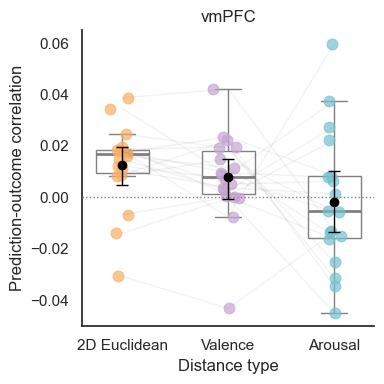

In [31]:
regions_to_test = ['OFC2016ConstantinescuR5']#,'HC']
region_names = ['vmPFC'] # 'vmPFC', 'Hippocampus'
region_filenames = ['vmpfc']#, 'hc'
region_colors = [['#F9B063','#C7A5D4','#75C1D0']]#,'#f1b584']]#['#7ca9cc','#7ca9cc', '#70c17f'] # '#70c17f','#7ca9cc'
#'#CAC9E7'], inner_edgecolors=['#8EA517','#974DA2'],
y_to_test = 'corr'#'percent_ceiling'
y_range = (-2, 2.5) if y_to_test == 'percent_ceiling' else None
y_decimal = 3 if y_to_test =='corr' else None
for region_to_test, region_to_test_name, region_to_test_filename, region_to_test_color in zip(regions_to_test, region_names, region_filenames, region_colors): 
      y_range = (-0.009, 0.012) if y_to_test == 'corr' and region_to_test == 'HC' else y_range
      y_decimal = None if region_to_test_name == 'vmPFC' else y_decimal
      print(f'Distance types in {region_to_test_name}')
      data_to_plot = data_all_distance[(data_all_distance['region'] == region_to_test) & (data_all_distance['source'] == 'Subavg')]
      print(bootstrap_ci(data_to_plot, 'corr', ['distance_type'])
            .merge(sign_flip_permutation(data_to_plot, 'corr', ['distance_type'], report_bonferroni=True), on=['distance_type'], how='left').to_string())


      va_df = data_to_plot[data_to_plot['distance_type'] == 'va']
      distance_to_compare_df = data_to_plot[(data_to_plot['distance_type'].isin(['v', 'a']))]
      diff_corr = va_df['corr'].values - (distance_to_compare_df[distance_to_compare_df['distance_type'] == 'v']['corr'].values + distance_to_compare_df[distance_to_compare_df['distance_type'] == 'a']['corr'].values) / 2
      distance_diff_df = pd.DataFrame({'region': va_df['region'].values, 'source': va_df['source'].values, 'diff_corr': diff_corr})
      print(f'Difference between Euclidean distance and unidimensional distance in {region_to_test_name}')
      print(bootstrap_ci(distance_diff_df, 'diff_corr', ['region', 'source'])
            .merge(sign_flip_permutation(distance_diff_df, 'diff_corr', ['region', 'source']), on=['region', 'source'], how='left').to_string())


      data_to_plot = data_to_plot[data_to_plot['distance_type'].isin(['va','v','a'])].reset_index(drop=True)
      data_to_plot['distance_type'] = pd.Categorical(data_to_plot['distance_type'], categories=['va','v','a'], ordered=True)
      stats_df = bootstrap_ci(data_to_plot, y_to_test, ['distance_type'])

      plot_subjectConnected_performance_scatter_wbox(data_to_plot, 'distance_type', y_to_test, 'test_subject', stats_df,
                                                condition_order=['va','v','a'], 
                                                condition_labels=['2D Euclidean','Valence','Arousal'],
                                                fill_colors=region_to_test_color,
                                                edge_colors=region_to_test_color,
                                                connect_subjects=True, line_alpha=0.03,
                                                plot_box=True,plot_bar=False,box_edgecolor='gray',errorbar_color='black',
                                                figsize=(4,4), title=f'{region_to_test_name}', 
                                                ylabel='Prediction-outcome correlation' if y_to_test == 'corr' else 'Prediction-outcome correlation\n(normalized by noise ceiling)', 
                                                xlabel='Distance type', yrange=y_range,#(1, 3.5), 
                                                ytick_decimals=y_decimal,
                                                dotted_yline=0, jitter=0.05, ax=None,
                                                save_svg=True,
                                                save=f'./outputs/vector_plots/distances_encoding_{y_to_test}_{region_to_test_filename}.svg')

corr
                    region      mean  ci_lower  ci_upper         d  test_stat     p_val  bonferroni_p_val
0  OFC2016ConstantinescuR5  0.012665  0.004911  0.019423  0.801220   0.012665  0.002100          0.006299
1                       HC  0.001748  0.000471  0.003030  0.627842   0.001748  0.007999          0.023998
2                      ERC  0.000492 -0.001578  0.002606  0.107913   0.000492  0.325967          0.977902
percent_ceiling
                    region      mean  ci_lower  ci_upper         d  test_stat     p_val
0  OFC2016ConstantinescuR5  0.380914  0.147697  0.584168  0.801220   0.380914  0.002100
1                       HC  0.380414  0.102556  0.659500  0.627842   0.380414  0.007999
2                      ERC  0.124095 -0.398336  0.658048  0.107913   0.124095  0.325967


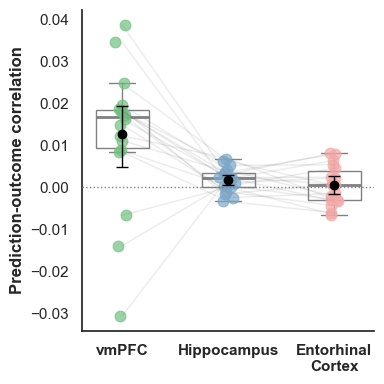

In [23]:
regions_to_plot = ['OFC2016ConstantinescuR5', 'HC', 'ERC']
distance_to_plot = 'va'
data_to_plot = data_all_distance[(data_all_distance['distance_type'] == distance_to_plot) & (data_all_distance['region'].isin(regions_to_plot)) & (data_all_distance['source'] == 'Subavg')]
data_to_plot['region'] = pd.Categorical(data_to_plot['region'], categories=regions_to_plot, ordered=True)
diff_data_to_test = diff_data[(diff_data['distance_type'] == distance_to_plot) & (diff_data['region'].isin(regions_to_plot)) & (diff_data['source'] == 'Subavg')]

stats_df = bootstrap_ci(data_to_plot, 'corr', ['region'])
print('corr')
print(stats_df.merge(sign_flip_permutation(data_to_plot, 'corr', ['region'], report_bonferroni=True), on=['region'], how='left').to_string())
#print(bootstrap_ci(diff_data_to_test, 'diff_corr', ['region']).merge(sign_flip_permutation(diff_data_to_test, 'diff_corr', ['region']), on=['region'], how='left').to_string())
print('percent_ceiling')
print(bootstrap_ci(data_to_plot, 'percent_ceiling', ['region']).merge(sign_flip_permutation(data_to_plot, 'percent_ceiling', ['region']), on=['region'], how='left').to_string())
#print(bootstrap_ci(diff_data_to_test, 'diff_percent_ceiling', ['region']).merge(sign_flip_permutation(diff_data_to_test, 'diff_percent_ceiling', ['region']), on=['region'], how='left').to_string())

    
plot_subjectConnected_performance_scatter_wbox(data_to_plot, 'region', y_value, 'test_subject', stats_df,
                                            condition_order=regions_to_plot, 
                                            condition_labels=['vmPFC','Hippocampus','Entorhinal\nCortex'],
                                            fill_colors=['#70c17f','#7ca9cc','#F4A9A7'],
                                            edge_colors=['#70c17f','#7ca9cc','#F4A9A7'],
                                            connect_subjects=True, line_alpha=0.05,
                                            plot_box=True,plot_bar=False,box_edgecolor='gray',errorbar_color='black',
                                            figsize=(4,4), title='', 
                                            ylabel='Prediction-outcome correlation', 
                                            xlabel='', yrange=None,#(1, 3.5), 
                                            dotted_yline=0, jitter=0.03, ax=None,
                                            save = './outputs/distances_encoding_performance_vmpfchcec.jpg')
            

#### Pattern expression & choice behavior

In [4]:
sources = ['Subavg', 'Subspec']
modality_to_use = ['both_modalities']#, 'face', 'word']
distance_types = ['va', 'v', 'a', 'judged', 'catCosine', 'catMax','catDominantAvg']
regions_to_plot = ['OFC2016ConstantinescuR5', 'HC', 'ERC','aHC','pHC']
Yproj_column = 'Yproj'
data_all_distance = pd.DataFrame()
for modality in modality_to_use:
    for source in sources:
        for distance_type in distance_types:
            for region in regions_to_plot:
                result_dir = f'./outputs/singleTrialBetaAnalysis/noICA/incl_all_subs_trials/distanceCentered_multivariate_encoding_yhat_ytest/unsmoothed/{modality}/{source}/{distance_type}/csv/beh_Yproj_raw_wDistance_{region}.csv'
                df = pd.read_csv(result_dir)
                #df['Yproj'] = (df['Yproj'] - df['Yproj'].mean()) / df['Yproj'].std()
                df['distance_type'] = distance_type
                df['modality'] = modality
                df['source'] = source
                df['region'] = region
                data_all_distance = pd.concat([data_all_distance, df])


In [5]:
distance_to_plot = ['va', 'v', 'a', 'judged', 'catCosine', 'catMax']
data_to_plot = data_all_distance[(data_all_distance['distance_type'].isin(distance_to_plot)) &(data_all_distance['source'] == 'Subavg')]
data_to_plot['Yproj'] = data_to_plot.groupby('test_subject')['Yproj'].transform(lambda x: (x - x.mean()) )

n_bins = 4  #  same number of bins for all subjects
count_ratios = []

for region in regions_to_plot:
    for distance_type in distance_to_plot:  
        for sub, df_sub in data_to_plot[(data_to_plot['distance_type'] == distance_type) & (data_to_plot['region'] == region)].groupby('test_subject'):
            # create quantile bins so each bin has roughly equal number of trials
            df_sub['bin'] = pd.qcut(df_sub['Yproj'], q=n_bins, labels=False, duplicates='drop')
            n_consistent = df_sub.groupby('bin')['consistency'].sum()
            n_inconsistent = df_sub.groupby('bin')['consistency'].apply(lambda x: (x == 0).sum())
            n_trials = df_sub.groupby('bin')['consistency'].count()
            ratio = n_consistent / n_trials
            # for bins where no inconsistent trials, set ratio to nan (to avoid divide by zero)
            bin_stats = pd.DataFrame({
                'bin': ratio.index,
                'ratio': ratio.values,
                'n_trials': n_trials.values
            }).reset_index(drop=True)
            bin_stats['subject'] = sub
            bin_stats['distance_type'] = distance_type
            bin_stats['region'] = region
            count_ratios.append(bin_stats)

count_ratios = pd.concat(count_ratios, ignore_index=True)

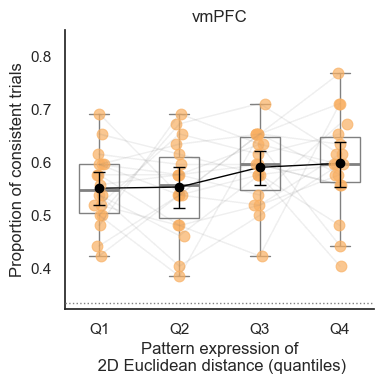

In [26]:
region_to_plot = 'OFC2016ConstantinescuR5'
distance_to_plot = 'va'#['va', 'v', 'a', 'judged', 'catCosine', 'catMax']

data_to_plot = count_ratios[(count_ratios['distance_type'] == distance_to_plot) & (count_ratios['region']== region_to_plot)]
stats_df_to_plot = bootstrap_ci(data_to_plot, 'ratio', ['region', 'bin'])
plot_subjectConnected_performance_scatter_wbox(data_to_plot, 'bin', 'ratio', 'subject', stats_df_to_plot,
                                            condition_order=[0, 1, 2, 3], 
                                            condition_labels=['Q1','Q2','Q3','Q4'],#['vmPFC\n(literature)','vmPFC\n(this study)','Hippocampus','Entorhinal\nCortex'],
                                            fill_colors=['#F9B063']*4,#['#7ca9cc']*4
                                            edge_colors=['#F9B063']*4,#['#7ca9cc']*4, 
                                            connect_subjects=True, line_alpha=0.03,
                                            plot_box=True,plot_bar=False,box_edgecolor='gray',errorbar_color='black',
                                            figsize=(4,4), title='vmPFC', 
                                            ylabel='Proportion of consistent trials', 
                                            xlabel='Pattern expression of\n 2D Euclidean distance (quantiles)', yrange=(0.35,0.85),#(1, 3.5), 
                                            dotted_yline=1/3, jitter=0.03, ax=None,
                                            connect_errorbar_means=True,
                                            save_svg=True,
                                            save = './outputs/vector_plots/pattern_expression_vmpfc_consistency.svg'
                                            )

### On-off Contrast

In [ ]:
data_dir = './outputs/singleTrialBetaAnalysis/noICA/incl_all_subs_trials/onoffGridcontrast_multivariate/unsmoothed'
sources = ['Subavg','Subspec']#,'SubavgtoSubspec','SubspectoSubavg']
regions = ['OFC2016ConstantinescuR5','vmPFC2016ConstantinescuR5','HC','ERC','vmPFC2019Bao2R5', 'vmPFC2019BaoR5']#['vmPFCCurrentStudy', 'OFC2016Constantinescu', 'vmPFC2016Constantinescu', 'ERC']
periodicity = [3, 4, 5, 6, 7, 8]
cross_validations = ['xModalityRun', 'xModality']
y_value = 'contrast_value'
filename = 'contrast_values.csv' if y_value == 'contrast_value' else 'beta_alignment_va_cat_id.csv'
data_all = pd.DataFrame()
for source in sources:
    for period in periodicity:
        for cross_validation in cross_validations:
            result_dir = f'{data_dir}/{source}/periodicity{period}/{cross_validation}/phi_voxelComponentAverage/singleTrialBeta/csv/{filename}'
            df = pd.read_csv(result_dir)
            if y_value == 'beta_alignment':
                df = df.dropna()
                df['subject'] = df['subject'].astype(int)
                df['beta_alignment'] = df['beta_alignment'].astype(float)
                df['contrast_value'] = df['contrast_value'].astype(float)
            df = df.groupby(['subject', 'region']).agg({y_value: 'mean', 'contrast_value': 'mean'}).reset_index()
            df['periodicity'] = str(period)
            df['source'] = source
            df['cross_validation'] = cross_validation
            #drop subject 14 with source is subspec
            if source == 'Subspec':
                df = df[df['subject'] != 14]
            
            data_all = pd.concat([data_all, df])
data_all = data_all[data_all['region'].isin(regions)]
#data_all['region'] = pd.Categorical(data_all['region'], categories=regions, ordered=True)
print(pd.merge(bootstrap_ci(data_all[data_all['region'].isin(regions)], y_value, ['periodicity', 'source', 'region']),
               sign_flip_permutation(data_all[data_all['region'].isin(regions)], y_value, ['periodicity', 'source', 'region']),
               on=['periodicity', 'source', 'region'], how='left').to_string(max_rows=None, max_cols=None))
#print(one_sample_t_test(data_all[data_all['region'].isin(regions)], y_value, ['periodicity', 'source', 'region']))#, 'cross_validation'])
#print paired t-test between periodicity 6 and all other periodicties separately for each region and source
data_avg = data_all.groupby(['subject', 'region', 'periodicity', 'source']).agg({y_value: 'mean'}).reset_index()
diff_data = pd.DataFrame()
diffavg_data = pd.DataFrame()
for region in regions:
    for source in sources:
        data_avg_region_source = data_avg[(data_avg['region'] == region) & (data_avg['source'] == source)]
        data_avg_region_source_periodicity6 = data_avg_region_source[data_avg_region_source['periodicity'] == '6']
        data_avg_region_source_periodicity6_other = data_avg_region_source[data_avg_region_source['periodicity'] != '6']
        for period in data_avg_region_source_periodicity6_other['periodicity'].unique():
            data_avg_region_source_periodicity6_other_period = data_avg_region_source_periodicity6_other[data_avg_region_source_periodicity6_other['periodicity'] == period]
            #print(region, source, period)
            #get the difference between the two (difference between y_value for each subject and concatenate each subject's difference)

            merged_df = pd.merge(data_avg_region_source_periodicity6[['subject', y_value]],data_avg_region_source_periodicity6_other_period[['subject', y_value]],on='subject',suffixes=('_6', f'_{period}'))
            diff_data = pd.concat([diff_data, pd.DataFrame({'region': region,'source': source,'periodicity': period,'diff': merged_df[f'{y_value}_6'] - merged_df[f'{y_value}_{period}']})], ignore_index=True)
        other_avg = (data_avg_region_source_periodicity6_other.groupby('subject', as_index=False)[y_value].mean().rename(columns={y_value: f'{y_value}_otherMean'}))
        merged_df = pd.merge(data_avg_region_source_periodicity6[['subject', y_value]].rename(columns={y_value: f'{y_value}_6'}),other_avg,on='subject')
        diffavg_data = pd.concat([diffavg_data, pd.DataFrame({'region': region,'source': source,'periodicity': 'mean_other','diff': merged_df[f'{y_value}_6'] - merged_df[f'{y_value}_otherMean']})], ignore_index=True)
print('6-fold vs other folds')   
print(pd.merge(bootstrap_ci(diff_data, 'diff', ['region', 'source', 'periodicity']),
               sign_flip_permutation(diff_data, 'diff', ['region', 'source', 'periodicity']),
               on=['region', 'source', 'periodicity'], how='left').to_string(max_rows=None, max_cols=None))
print('6-fold vs average of other folds')           
print(pd.merge(bootstrap_ci(diffavg_data, 'diff', ['region', 'source', 'periodicity']),
               sign_flip_permutation(diffavg_data, 'diff', ['region', 'source', 'periodicity']),
               on=['region', 'source', 'periodicity'], how='left').to_string(max_rows=None, max_cols=None))

#### 6-fold, All regions

In [5]:
regions_to_plot = ['OFC2016ConstantinescuR5','HC','ERC']
data_to_plot = data_all[(data_all['periodicity'] == '6') & (data_all['region'].isin(regions_to_plot))]
data_to_plot['region'] = pd.Categorical(data_to_plot['region'], categories=regions_to_plot, ordered=True)
stats_df = bootstrap_ci(data_to_plot, target_col=y_value, group_vars=['periodicity', 'source','region'])
to_report = pd.merge(stats_df, sign_flip_permutation(data_to_plot, y_value, ['periodicity', 'source', 'region'], report_bonferroni=True), on=['periodicity', 'source', 'region'], how='left')
print(to_report[to_report['source'] == 'Subavg'].to_string())

region_diff_data = pd.DataFrame()
for periodicity in ['6']:
    for source in sources:
        data_avg_perd_source = data_avg[(data_avg['periodicity'] == periodicity) & (data_avg['source'] == source)]
        data_avg_perd_source_ofc = data_avg_perd_source[data_avg_perd_source['region'] == 'OFC2016ConstantinescuR5']

        for region_to_compare in ['HC', 'ERC']:
            data_avg_perd_source_other = data_avg_perd_source[data_avg_perd_source['region'] == region_to_compare]
            region_diff_data = pd.concat([region_diff_data, pd.DataFrame({'region': region_to_compare,'source': source,'periodicity': periodicity,'diff': data_avg_perd_source_ofc[y_value].values - data_avg_perd_source_other[y_value].values})], ignore_index=True)
print('vmPFC vs HC/ERC')
to_report = pd.merge(bootstrap_ci(region_diff_data, 'diff', ['region', 'source', 'periodicity']), 
                     sign_flip_permutation(region_diff_data, 'diff', ['region', 'source', 'periodicity'], report_bonferroni=True), on=['region', 'source', 'periodicity'], how='left')
print(to_report[to_report['source'] == 'Subavg'].to_string())

  periodicity  source                   region      mean  ci_lower  ci_upper         d  test_stat     p_val  bonferroni_p_val
0           6  Subavg  OFC2016ConstantinescuR5  0.007165  0.003408  0.011158  0.612506   0.007165  0.000100          0.000600
1           6  Subavg                       HC  0.001140 -0.000504  0.002832  0.222042   0.001140  0.097690          0.586141
2           6  Subavg                      ERC -0.000240 -0.002401  0.002054 -0.035379  -0.000240  0.586041          1.000000
vmPFC vs HC/ERC
  region  source periodicity      mean  ci_lower  ci_upper         d  test_stat   p_val  bonferroni_p_val
0    ERC  Subavg           6  0.007405  0.003204  0.011766  0.788581   0.007405  0.0023          0.009199
2     HC  Subavg           6  0.006025  0.002035  0.010471  0.657676   0.006025  0.0042          0.016798


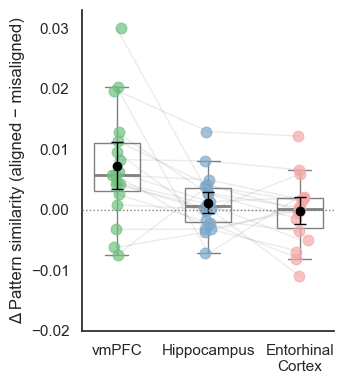

In [6]:
data_to_plot = data_to_plot[data_to_plot['source'] == 'Subavg']
data_to_plot = data_to_plot.groupby(['subject', 'region', 'periodicity', 'source']).agg({y_value: 'mean'}).reset_index()
stats_df_to_plot = stats_df[stats_df['source'] == 'Subavg']

plot_subjectConnected_performance_scatter_wbox(data_to_plot, 'region', y_value, 'subject', stats_df_to_plot,
                                                condition_order=regions_to_plot, 
                                                condition_labels=['vmPFC','Hippocampus','Entorhinal\nCortex'],#['vmPFC\n(literature)','vmPFC\n(this study)','Hippocampus','Entorhinal\nCortex'],
                                                fill_colors=['#70c17f','#7ca9cc','#F4A9A7'],#['#70c17f','#33CC99','#7ca9cc','#F4A9A7'], #FE8D01'
                                                #edge_colors=['#FE8D01','#F4A9A7','#7ca9cc','#70c17f'], 
                                                connect_subjects=True, line_alpha=0.05,
                                                plot_box=True,plot_bar=False,box_edgecolor='gray',errorbar_color='black',
                                                figsize=(3.6,4), title=None, 
                                                ylabel='Δ Pattern similarity (aligned − misaligned)', 
                                                xlabel='', yrange=(-0.02, 0.033), dotted_yline=0, jitter=0.03, ax=None,
                                                #density_scaled_jitter=True
                                                save_svg=True,
                                                #save='./outputs/vector_plots/contrast_values_vmpfcliteraturehcerc_subavg_6fold.svg'
                                                )
                                                #save = './outputs/contrast_values_vmpfcliteraturehcerc_subavg_6fold.jpg')

#### Bins

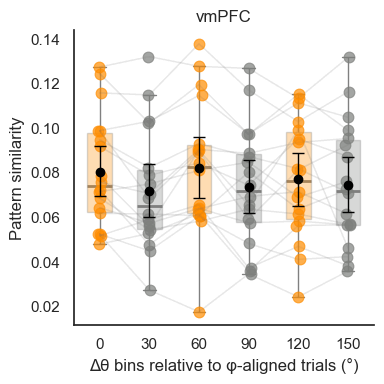

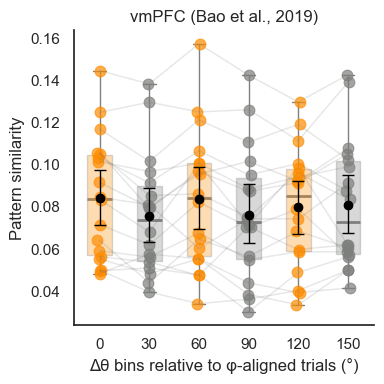

In [7]:
cross_validations = ['xModalityRun', 'xModality']#,'xRun']
data_all_bin = pd.DataFrame()
for cross_validation in cross_validations:
    bin_values = pd.read_csv(f'./outputs/singleTrialBetaAnalysis/noICA/incl_all_subs_trials/onoffGridcontrast_multivariate/unsmoothed/Subavg/periodicity6/{cross_validation}/phi_voxelComponentAverage/singleTrialBeta/csv/bin_means.csv')
    bin_values = bin_values.groupby(['bin_centers', 'subject', 'region']).agg({'bin_means': 'mean'}).reset_index()
    bin_values['cross_validation'] = cross_validation
    data_all_bin = pd.concat([data_all_bin, bin_values])

for reg, reg_name, file in zip(['OFC2016ConstantinescuR5','vmPFC2019BaoR5'],['vmPFC', 'vmPFC (Bao et al., 2019)'],['literature','Bao2019']):
    region = [reg]#'vmPFCcurrentStudyR5']#['OFC2016ConstantinescuR5']#, 'OFC2016Constantinescu']#,'vmPFCCurrentStudy', 'OFC2016Constantinescu', 'vmPFC2016Constantinescu']
    bin_values = data_all_bin[data_all_bin['region'].isin(region)]
    bin_values = bin_values.groupby(['bin_centers', 'subject', 'region']).agg({'bin_means': 'mean'}).reset_index()
    bin_order =  bin_values['bin_centers'].unique()#[0, 30, 60, 90, 120, 150]
    bin_values['bin_centers'] = pd.Categorical(bin_values['bin_centers'], categories=bin_order, ordered=True)
    stats_df_to_plot = bootstrap_ci(bin_values, target_col='bin_means', group_vars=['bin_centers'])

    plot_subjectConnected_performance_scatter_wbox(bin_values, 'bin_centers', 'bin_means', 'subject',stats_df_to_plot,
                                            title=reg_name,
                                            condition_order=bin_order, 
                                            condition_labels=bin_order,plot_scatter=True,
                                            fill_colors=['#FE8D01', '#7d7f7c','#FE8D01', '#7d7f7c','#FE8D01', '#7d7f7c'], #FE8D01'
                                            #edge_colors=['#FE8D01','#F4A9A7','#7ca9cc','#70c17f'], 
                                            connect_subjects=True, line_alpha=0.03,
                                            plot_box=True,plot_bar=False,box_edgecolor='gray',errorbar_color='black',box_fillcolors=['#FE8D01', '#7d7f7c','#FE8D01', '#7d7f7c','#FE8D01', '#7d7f7c'],
                                            figsize=(4,4),
                                            ylabel='Pattern similarity', 
                                            xlabel='Δθ bins relative to φ-aligned trials (°)', yrange=None, jitter=0.02, ax=None,
                                            #save_svg=True,
                                            #save=f'./outputs/vector_plots/vmPFC{file}_bin_means_subavg.svg'
                                            )
                                            #save = f'./outputs/vmPFC{file}_bin_means.jpg')

#### Control folds

In [56]:
print('Effect of control folds')
print(pd.merge(bootstrap_ci(data_all[(data_all['region'].isin(['OFC2016ConstantinescuR5'])  & (data_all['periodicity'] != '6'))], y_value, ['periodicity', 'source', 'region']),
               sign_flip_permutation(data_all[(data_all['region'].isin(['OFC2016ConstantinescuR5']) & (data_all['periodicity'] != '6'))], y_value, ['periodicity', 'source', 'region']),
               on=['periodicity', 'source', 'region'], how='left').to_string(max_rows=None, max_cols=None))
print('Difference between 6-fold and other folds')
print(pd.merge(bootstrap_ci(diff_data[diff_data['region'].isin(['OFC2016ConstantinescuR5'])], 'diff', ['region', 'source', 'periodicity']),
               sign_flip_permutation(diff_data[diff_data['region'].isin(['OFC2016ConstantinescuR5'])], 'diff', ['region', 'source', 'periodicity']),
               on=['region', 'source', 'periodicity'], how='left').drop(columns=['test_stat']).to_string(max_rows=None, max_cols=None))
print(pd.merge(bootstrap_ci(diffavg_data[diffavg_data['region'].isin(['OFC2016ConstantinescuR5'])], 'diff', ['region', 'source', 'periodicity']),
               sign_flip_permutation(diffavg_data[diffavg_data['region'].isin(['OFC2016ConstantinescuR5'])], 'diff', ['region', 'source', 'periodicity']),
               on=['region', 'source', 'periodicity'], how='left').drop(columns=['test_stat']).to_string(max_rows=None, max_cols=None))

Effect of control folds
  periodicity   source                   region      mean  ci_lower  ci_upper         d  test_stat     p_val
0           3   Subavg  OFC2016ConstantinescuR5 -0.004288 -0.006846 -0.001688 -0.542012  -0.004288  0.998900
1           3  Subspec  OFC2016ConstantinescuR5 -0.001487 -0.004484  0.001420 -0.168277  -0.001487  0.835416
2           4   Subavg  OFC2016ConstantinescuR5 -0.002767 -0.006377  0.000993 -0.245066  -0.002767  0.924408
3           4  Subspec  OFC2016ConstantinescuR5 -0.000149 -0.003228  0.003235 -0.015470  -0.000149  0.533747
4           5   Subavg  OFC2016ConstantinescuR5 -0.001542 -0.004020  0.001108 -0.198609  -0.001542  0.880212
5           5  Subspec  OFC2016ConstantinescuR5 -0.000629 -0.004671  0.003484 -0.051842  -0.000629  0.618638
6           7   Subavg  OFC2016ConstantinescuR5  0.000655 -0.002490  0.004108  0.065144   0.000655  0.359164
7           7  Subspec  OFC2016ConstantinescuR5 -0.001748 -0.004476  0.000914 -0.218785  -0.001748  0.89

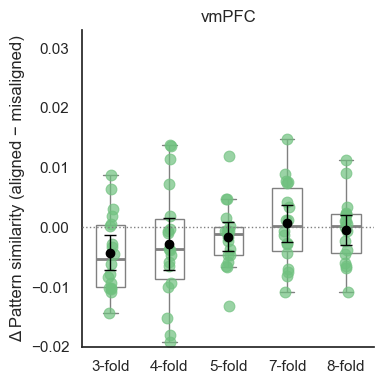

In [12]:
for reg, reg_name,color,file in zip(['OFC2016ConstantinescuR5'],['vmPFC'],['#70c17f'], ['literature']):
    data_to_plot = data_all[(data_all['source'] == 'Subavg') & (data_all['region'].isin([reg])) & (data_all['periodicity'] != '6')]
    data_to_plot = data_to_plot.groupby(['subject', 'region', 'periodicity', 'source']).agg({y_value: 'mean'}).reset_index()
    data_to_plot['periodicity'] = pd.Categorical(data_to_plot['periodicity'], categories=['3','4','5','7','8'], ordered=True)
    stats_df_to_plot = bootstrap_ci(data_to_plot, target_col=y_value, group_vars=['periodicity'])

    plot_subjectConnected_performance_scatter_wbox(data_to_plot, 'periodicity', y_value, 'subject', stats_df_to_plot,
                                                    title=reg_name,
                                                    condition_order=['3','4','5','7','8'], 
                                                    condition_labels=['3-fold','4-fold','5-fold','7-fold','8-fold'],
                                                    fill_colors=[color]*5, #['#70c17f','#33CC99','#7ca9cc','#F4A9A7'], #FE8D01'
                                                    #edge_colors=['#FE8D01','#F4A9A7','#7ca9cc','#70c17f'], 
                                                    connect_subjects=False,
                                                    plot_box=True,plot_bar=False,box_edgecolor='gray',errorbar_color='black',
                                                    figsize=(4,4), 
                                                    ylabel='Δ Pattern similarity (aligned − misaligned)', 
                                                    xlabel='', dotted_yline=0, jitter=0.02, ax=None,
                                                    yrange=(-0.02, 0.033),
                                                    save_svg=True,
                                                    save=f'./outputs/vector_plots/contrast_values_vmpfc{file}_subavg_controlfolds.svg')
                                                   #save = f'./outputs/contrast_values_vmpfc{file}_subavg_controlfolds.jpg')

  periodicity      mean  ci_lower  ci_upper         d  test_stat     p_val
0           3 -0.003908 -0.006999 -0.000711 -0.573380  -0.003908  0.981902
1           4 -0.000585 -0.004859  0.004188 -0.059373  -0.000585  0.589141
2           5 -0.001942 -0.005189  0.001061 -0.289622  -0.001942  0.872313
3           6  0.005514  0.001398  0.009642  0.620703   0.005514  0.010799
4           7  0.001005 -0.003620  0.006024  0.096775   0.001005  0.352365
5           8  0.001106 -0.001468  0.003894  0.191353   0.001106  0.228877
Difference between 6-fold and other folds
           region   source periodicity      mean  ci_lower  ci_upper         d     p_val
0  vmPFC2019BaoR5   Subavg  mean_other  0.006379  0.001553  0.011328  0.602528  0.011899
1  vmPFC2019BaoR5  Subspec  mean_other  0.001607 -0.002964  0.005846  0.173424  0.247575
  periodicity      mean  ci_lower  ci_upper         d  test_stat     p_val
0           3 -0.001870 -0.005081  0.001341 -0.266174  -0.001870  0.855714
1           4 -0

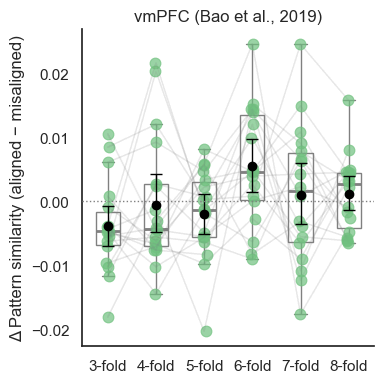

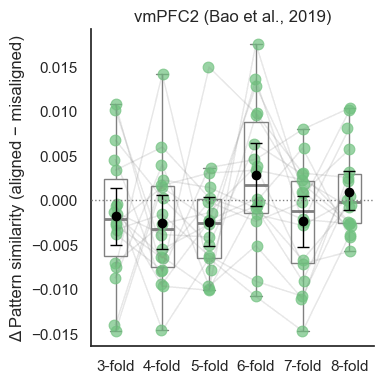

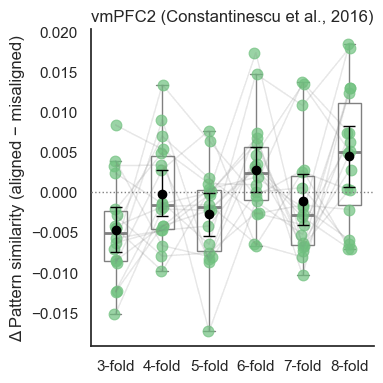

In [13]:
for reg, reg_name,color,file in zip(['vmPFC2019BaoR5','vmPFC2019Bao2R5','vmPFC2016ConstantinescuR5'],
                                                                ['vmPFC (Bao et al., 2019)','vmPFC2 (Bao et al., 2019)','vmPFC2 (Constantinescu et al., 2016)'],
                                                                ['#70c17f', '#70c17f', '#70c17f'], 
                                                                ['Bao2019', 'Bao22019', 'Constantinescu2016vmPFC']):
    data_to_plot = data_all[(data_all['source'] == 'Subavg') & (data_all['region'] == reg)]
    data_to_plot = data_to_plot.groupby(['subject', 'region', 'periodicity', 'source']).agg({y_value: 'mean'}).reset_index()
    data_to_plot['periodicity'] = pd.Categorical(data_to_plot['periodicity'], categories=['3','4','5','6','7','8'], ordered=True)
    stats_df_to_plot = bootstrap_ci(data_to_plot, target_col=y_value, group_vars=['periodicity'])
    print(stats_df_to_plot.merge(sign_flip_permutation(data_to_plot, y_value, ['periodicity']), on=['periodicity'], how='left').to_string())

    print('Difference between 6-fold and other folds')
    print(pd.merge(bootstrap_ci(diffavg_data[diffavg_data['region'].isin([reg])], 'diff', ['region', 'source', 'periodicity']),
                sign_flip_permutation(diffavg_data[diffavg_data['region'].isin([reg])], 'diff', ['region', 'source', 'periodicity']),
                on=['region', 'source', 'periodicity'], how='left').drop(columns=['test_stat']).to_string(max_rows=None, max_cols=None))

    plot_subjectConnected_performance_scatter_wbox(data_to_plot, 'periodicity', y_value, 'subject', stats_df_to_plot,
                                                    title=reg_name,
                                                    condition_order=['3','4','5','6','7','8'], 
                                                    condition_labels=['3-fold','4-fold','5-fold','6-fold','7-fold','8-fold'],
                                                    fill_colors=[color]*6, #['#70c17f','#33CC99','#7ca9cc','#F4A9A7'], #FE8D01'
                                                    #edge_colors=['#FE8D01','#F4A9A7','#7ca9cc','#70c17f'], 
                                                    connect_subjects=True, line_alpha=0.03,
                                                    plot_box=True,plot_bar=False,box_edgecolor='gray',errorbar_color='black',
                                                    figsize=(4,4), 
                                                    ylabel='Δ Pattern similarity (aligned − misaligned)', 
                                                    xlabel='', dotted_yline=0, jitter=0.02, ax=None,
                                                    yrange=None,
                                                    #save_svg=True,      
                                                   #save = f'./outputs/vector_plots/contrast_values_vmpfc{file}_subavg_controlfolds.svg'
                                                   )

##### Individual ratings

  periodicity   source                   region      mean  ci_lower  ci_upper         d  test_stat     p_val
0           3  Subspec  OFC2016ConstantinescuR5 -0.001487 -0.004464  0.001459 -0.167557  -0.001487  0.767323
1           4  Subspec  OFC2016ConstantinescuR5 -0.000149 -0.003298  0.003216 -0.015380  -0.000149  0.535546
2           5  Subspec  OFC2016ConstantinescuR5 -0.000629 -0.004669  0.003689 -0.050295  -0.000629  0.589641
3           6  Subspec  OFC2016ConstantinescuR5  0.004147 -0.000139  0.008420  0.329400   0.004147  0.061694
4           7  Subspec  OFC2016ConstantinescuR5 -0.001748 -0.004457  0.000822 -0.221263  -0.001748  0.828317
5           8  Subspec  OFC2016ConstantinescuR5  0.004430  0.000175  0.008828  0.342570   0.004430  0.073493
                    region   source periodicity      mean  ci_lower  ci_upper         d     p_val
0  OFC2016ConstantinescuR5  Subspec  mean_other  0.004064 -0.000504  0.008569  0.429296  0.052695


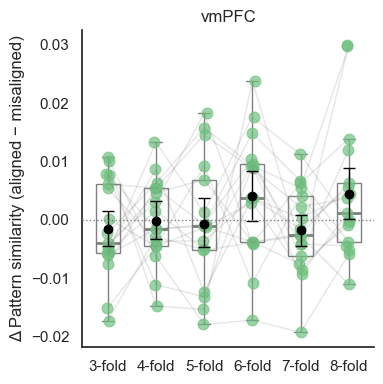

In [ ]:
regions_to_plot = ['OFC2016ConstantinescuR5','HC','ERC']
data_to_test = data_all[(data_all['region'].isin(regions_to_plot)) & (data_all['source'].isin(['Subavg','Subspec']))]
stats_df = bootstrap_ci(data_to_test, target_col=y_value, group_vars=['periodicity', 'source','region'])

for reg, reg_name,color,file in zip(['OFC2016ConstantinescuR5'],['vmPFC'],['#70c17f'], ['literature']):
    data_to_plot = data_all[(data_all['source'] == 'Subspec') & (data_all['region'] == reg)]
    data_to_plot = data_to_plot.groupby(['subject', 'region', 'periodicity', 'source']).agg({y_value: 'mean'}).reset_index()
    data_to_plot['periodicity'] = pd.Categorical(data_to_plot['periodicity'], categories=['3','4','5','6','7','8'], ordered=True)
    stats_df_to_plot = stats_df[(stats_df['region'] == reg) & (stats_df['source'] == 'Subspec')]

    print(stats_df_to_plot.merge(sign_flip_permutation(data_to_plot, y_value, ['periodicity']), on=['periodicity'], how='left').to_string())
    print(pd.merge(bootstrap_ci(diffavg_data[(diffavg_data['region'].isin([reg]) & (diffavg_data['source'] == 'Subspec'))], 'diff', ['region', 'source', 'periodicity']),
                sign_flip_permutation(diffavg_data[(diffavg_data['region'].isin([reg]) & (diffavg_data['source'] == 'Subspec'))], 'diff', ['region', 'source', 'periodicity']),
                on=['region', 'source', 'periodicity'], how='left').drop(columns=['test_stat']).to_string(max_rows=None, max_cols=None))

    plot_subjectConnected_performance_scatter_wbox(data_to_plot, 'periodicity', y_value, 'subject', stats_df_to_plot,
                                                    title=reg_name,
                                                    condition_order=['3','4','5','6','7','8'], 
                                                    condition_labels=['3-fold','4-fold','5-fold','6-fold','7-fold','8-fold'],
                                                    fill_colors=[color]*6, #['#70c17f','#33CC99','#7ca9cc','#F4A9A7'], #FE8D01'
                                                    #edge_colors=['#FE8D01','#F4A9A7','#7ca9cc','#70c17f'], 
                                                    connect_subjects=True, line_alpha=0.03,
                                                    plot_box=True,plot_bar=False,box_edgecolor='gray',errorbar_color='black',
                                                    figsize=(4,4), 
                                                    ylabel='Δ Pattern similarity (aligned − misaligned)', 
                                                    xlabel='', dotted_yline=0, jitter=0.02, ax=None,
                                                    yrange=None,
                                                    save_svg=True,
                                                   save = f'./outputs/vector_plots/contrast_values_vmpfc{file}_subspec_controlfolds.svg')

##### Confound control (## Set y_value = 'beta_alignment'!!!)

  periodicity      mean  ci_lower  ci_upper         d  test_stat     p_val
0           3 -0.001894 -0.004832  0.001249 -0.289965  -0.001894  0.876512
1           4 -0.002344 -0.006689  0.001907 -0.247844  -0.002344  0.834717
2           5 -0.001506 -0.004033  0.001134 -0.267321  -0.001506  0.851515
3           6  0.006332  0.002471  0.010622  0.722601   0.006332  0.002000
4           7  0.001693 -0.001481  0.005072  0.239282   0.001693  0.168683
5           8 -0.002029 -0.004654  0.000717 -0.350421  -0.002029  0.916808
Difference between 6-fold and other folds
                    region   source periodicity      mean  ci_lower  ci_upper         d    p_val
0  OFC2016ConstantinescuR5   Subavg  mean_other  0.007549  0.003475  0.011827  0.830292  0.00120
1  OFC2016ConstantinescuR5  Subspec  mean_other  0.002936 -0.001356  0.007109  0.326072  0.10329


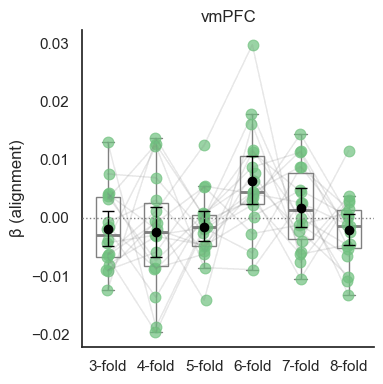

In [33]:
for reg, reg_name,color,file in zip(['OFC2016ConstantinescuR5'],['vmPFC'],['#70c17f'], ['literature']):
    data_to_plot = data_all[(data_all['source'] == 'Subavg') & (data_all['region'] == reg)]
    data_to_plot = data_to_plot.groupby(['subject', 'region', 'periodicity', 'source']).agg({y_value: 'mean'}).reset_index()
    data_to_plot['periodicity'] = pd.Categorical(data_to_plot['periodicity'], categories=['3','4','5','6','7','8'], ordered=True)
    stats_df_to_plot = bootstrap_ci(data_to_plot, target_col=y_value, group_vars=['periodicity'])
    print(stats_df_to_plot.merge(sign_flip_permutation(data_to_plot, y_value, ['periodicity']), on=['periodicity'], how='left').to_string())
    
    print('Difference between 6-fold and other folds')
    print(pd.merge(bootstrap_ci(diffavg_data[diffavg_data['region'].isin([reg])], 'diff', ['region', 'source', 'periodicity']),
                sign_flip_permutation(diffavg_data[diffavg_data['region'].isin([reg])], 'diff', ['region', 'source', 'periodicity']),
                on=['region', 'source', 'periodicity'], how='left').drop(columns=['test_stat']).to_string(max_rows=None, max_cols=None))

    plot_subjectConnected_performance_scatter_wbox(data_to_plot, 'periodicity', y_value, 'subject', stats_df_to_plot,
                                                    title=reg_name,
                                                    condition_order=['3','4','5','6','7','8'], 
                                                    condition_labels=['3-fold','4-fold','5-fold','6-fold','7-fold','8-fold'],
                                                    fill_colors=[color]*6, #['#70c17f','#33CC99','#7ca9cc','#F4A9A7'], #FE8D01'
                                                    #edge_colors=['#FE8D01','#F4A9A7','#7ca9cc','#70c17f'], 
                                                    connect_subjects=True, line_alpha=0.03,
                                                    plot_box=True,plot_bar=False,box_edgecolor='gray',errorbar_color='black',
                                                    figsize=(4,4), 
                                                    ylabel='β (alignment)', 
                                                    xlabel='', dotted_yline=0, jitter=0.02, ax=None,
                                                    yrange=None,
                                                    save_svg=True,
                                                   save = f'./outputs/vector_plots/beta_alignment_vmpfc{file}_subavg_controlfolds.svg')

#### Cross-modal

In [4]:
data_dir = './outputs/singleTrialBetaAnalysis/noICA/incl_all_subs_trials/onoffGridcontrast_multivariate/unsmoothed'
sources = ['Subavg','Subspec']
regions = ['OFC2016ConstantinescuR5']#,'vmPFCcurrentStudyR5']#['vmPFCCurrentStudy', 'OFC2016Constantinescu', 'vmPFC2016Constantinescu', 'ERC']
periodicity = [3, 4, 5, 6, 7, 8]
cross_validations = ['xModality','xRun']
cv_names = ['Cross-modal','Within-modal']
y_value = 'contrast_value' #'beta_alignment'#'contrast_value'
filename = 'contrast_values.csv' if y_value == 'contrast_value' else 'beta_alignment_va_cat_id.csv'
data_all_modal = pd.DataFrame()
for source in sources:
    for period in periodicity:
        for cross_validation in cross_validations:
            result_dir = f'{data_dir}/{source}/periodicity{period}/{cross_validation}/phi_voxelComponentAverage/singleTrialBeta/csv/{filename}'
            df = pd.read_csv(result_dir)
            if y_value == 'beta_alignment':
                df = df.dropna()
                df['subject'] = df['subject'].astype(int)
                df['beta_alignment'] = df['beta_alignment'].astype(float)
                df['contrast_value'] = df['contrast_value'].astype(float)
            df['periodicity'] = str(period)
            df['source'] = source
            df['cross_validation'] = cross_validation
            if source == 'Subspec':
                df = df[df['subject'] != 14]
            
            data_all_modal = pd.concat([data_all_modal, df])
data_all_modal = data_all_modal[data_all_modal['region'].isin(regions)]

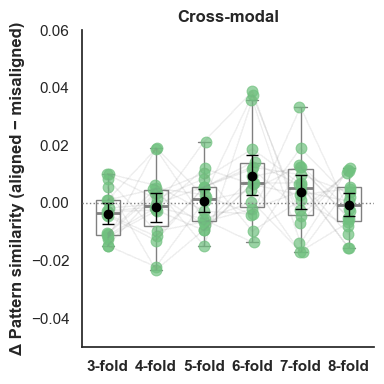

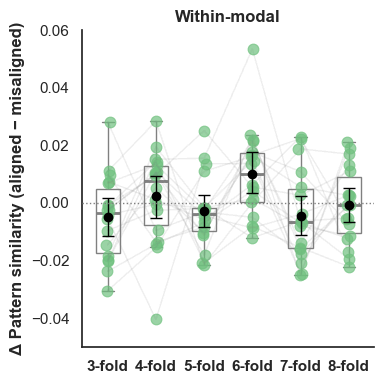

In [47]:
for cv,cv_name in zip(cross_validations,cv_names):
    data_to_plot = data_all_modal[(data_all_modal['source'] == 'Subavg') & (data_all_modal['cross_validation'] == cv)]
    data_to_plot = data_to_plot.groupby(['subject', 'region', 'periodicity', 'source']).agg({y_value: 'mean'}).reset_index()
    data_to_plot['periodicity'] = pd.Categorical(data_to_plot['periodicity'], categories=['3','4','5','6','7','8'], ordered=True)
    stats_df_to_plot = bootstrap_ci(data_to_plot, target_col=y_value, group_vars=['periodicity'])

    plot_subjectConnected_performance_scatter_wbox(data_to_plot, 'periodicity', y_value, 'subject', stats_df_to_plot,
                                                    title=f'{cv_name}',
                                                    condition_order=['3','4','5','6','7','8'], 
                                                    condition_labels=['3-fold','4-fold','5-fold','6-fold','7-fold','8-fold'],
                                                    fill_colors=['#70c17f']*6, #['#70c17f','#33CC99','#7ca9cc','#F4A9A7'], #FE8D01'
                                                    #edge_colors=['#FE8D01','#F4A9A7','#7ca9cc','#70c17f'], 
                                                    connect_subjects=True, line_alpha=0.02,
                                                    plot_box=True,plot_bar=False,box_edgecolor='gray',errorbar_color='black',
                                                    figsize=(4,4), 
                                                    ylabel='Δ Pattern similarity (aligned − misaligned)', 
                                                    xlabel='', dotted_yline=0, jitter=0.02, ax=None,
                                                    yrange=(-0.05, 0.06),
                                                    save = f'./outputs/contrast_values_vmpfcliterature_subavg_allfolds_{cv}.jpg')

test_run: face, cv: xModality
  periodicity      mean  ci_lower  ci_upper         d     p_val
0           3 -0.008395 -0.014107 -0.002439 -0.662529  0.992901
1           4  0.000275 -0.007571  0.007934  0.016367  0.471453
2           5  0.002347 -0.004929  0.009353  0.151725  0.268873
3           6  0.011668  0.001251  0.022420  0.506057  0.023398
4           7  0.005185 -0.003914  0.014764  0.256441  0.150185
5           8 -0.004379 -0.010779  0.002720 -0.303563  0.885611
                    region  source      mean  ci_lower  ci_upper         d  \
0  OFC2016ConstantinescuR5  Subavg  0.012661  0.001468  0.024097  0.512933   

   test_stat     p_val  
0   0.012661  0.046095  
test_run: word, cv: xModality
  periodicity      mean  ci_lower  ci_upper         d     p_val
0           3  0.000999 -0.002779  0.005239  0.114784  0.325267
1           4 -0.003209 -0.008690  0.002644 -0.260081  0.848015
2           5 -0.000997 -0.006328  0.005051 -0.080674  0.625437
3           6  0.007224  0.00

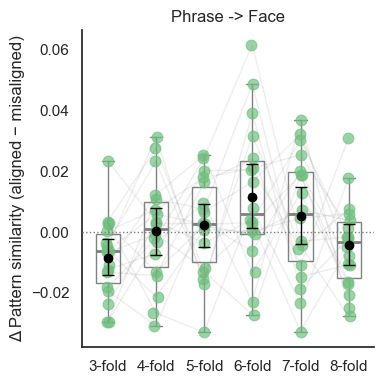

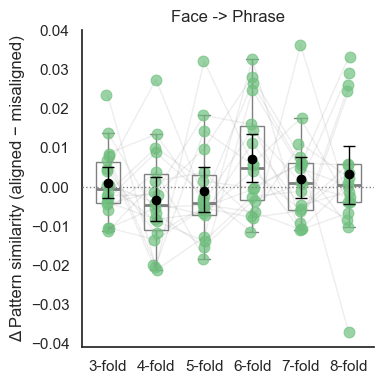

In [19]:
data_all_modal_to_plot=data_all_modal.copy()
data_all_modal_to_plot['test_runs'] = data_all_modal['test_runs'].replace({'face1': 'face', 'face2': 'face', 'word1': 'word', 'word2': 'word', 'face1_face2': 'face', 'word1_word2': 'word'})
for cv in ['xModality']:#cross_validations:
    for test_run in ['face','word']:
        data_to_plot = data_all_modal[(data_all_modal_to_plot['source'] == 'Subavg') & (data_all_modal_to_plot['cross_validation'] == cv) & (data_all_modal_to_plot['test_runs'] == test_run)]
        data_to_plot = data_to_plot.groupby(['subject', 'region', 'periodicity', 'source']).agg({y_value: 'mean'}).reset_index()
        data_to_plot['periodicity'] = pd.Categorical(data_to_plot['periodicity'], categories=['3','4','5','6','7','8'], ordered=True)
        stats_df_to_plot = bootstrap_ci(data_to_plot, target_col=y_value, group_vars=['periodicity'])
        print(f'test_run: {test_run}, cv: {cv}')
        print(pd.merge(bootstrap_ci(data_to_plot, target_col=y_value, group_vars=['periodicity']),
                       sign_flip_permutation(data_to_plot, target_col=y_value, group_vars=['periodicity']),
                       on=['periodicity'], how='left').drop(columns=['test_stat']).to_string(max_rows=None, max_cols=None))
        
        data_other_perd = data_to_plot[data_to_plot['periodicity'] != '6']
        data_other_perd = data_other_perd.groupby(['subject', 'region', 'source']).agg({y_value: 'mean'}).reset_index()
        data_other_perd['periodicity'] = 'other'
        data_perd6 = data_to_plot[data_to_plot['periodicity'] == '6']
        #difference between 6-fold and other folds for each subject
        data_diff = pd.merge(data_perd6, data_other_perd, on=['subject', 'region', 'source'], how='left')
        data_diff['diff'] = data_diff['contrast_value_x'] - data_diff['contrast_value_y']
        print(pd.merge(bootstrap_ci(data_diff, 'diff', ['region', 'source']), sign_flip_permutation(data_diff, 'diff', ['region', 'source'], alternative='two-sided'), on=['region', 'source'], how='left'))

        plot_subjectConnected_performance_scatter_wbox(data_to_plot, 'periodicity', y_value, 'subject', stats_df_to_plot,
                                                        title='Face -> Phrase' if test_run == 'word' else 'Phrase -> Face',
                                                        condition_order=['3','4','5','6','7','8'], 
                                                        condition_labels=['3-fold','4-fold','5-fold','6-fold','7-fold','8-fold'],
                                                        fill_colors=['#70c17f']*6, #['#70c17f','#33CC99','#7ca9cc','#F4A9A7'], #FE8D01'
                                                        #edge_colors=['#FE8D01','#F4A9A7','#7ca9cc','#70c17f'], 
                                                        connect_subjects=True, line_alpha=0.02,
                                                        plot_box=True,plot_bar=False,box_edgecolor='gray',errorbar_color='black',
                                                        figsize=(4,4), 
                                                        ylabel='Δ Pattern similarity (aligned − misaligned)', 
                                                        xlabel='', dotted_yline=0, jitter=0.02, ax=None,
                                                        yrange=None,
                                                   #save = f'./outputs/contrast_values_vmpfcliterature_subavg_controlfolds_{cv}_{test_run}.jpg'
                                                   )

In [28]:
data = data_all_modal_to_plot[(data_all_modal_to_plot['source'] == 'Subavg') & (data_all_modal_to_plot['cross_validation'] == 'xModality') & (data_all_modal_to_plot['periodicity'] == '6')]
#get the difference between face and word in test_runs for each subject
data = data.pivot(index=['subject', 'region', 'periodicity', 'source'], columns='test_runs', values='contrast_value').reset_index()
data['diff'] = data['face'] - data['word']
print('Difference between the two cross-modal conditions')
print(pd.merge(bootstrap_ci(data, 'diff', ['region']), sign_flip_permutation(data, 'diff', ['region'], alternative='two-sided'), on=['region'], how='left'))

Difference between the two cross-modal conditions
                    region      mean  ci_lower  ci_upper        d  test_stat  \
0  OFC2016ConstantinescuR5  0.004444 -0.006258  0.014935  0.19328   0.004444   

      p_val  
0  0.422558  


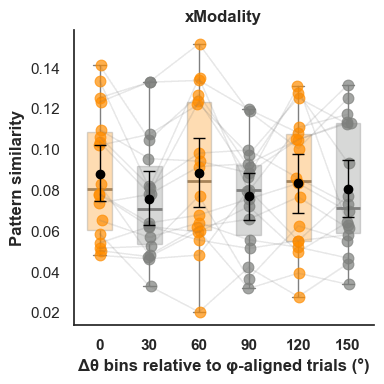

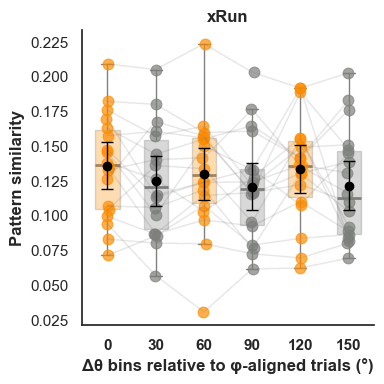

In [28]:
cross_validations = ['xModality','xRun']
regions = ['OFC2016ConstantinescuR5']
data_all_bin = pd.DataFrame()
for cross_validation in cross_validations:
    bin_values = pd.read_csv(f'./outputs/singleTrialBetaAnalysis/noICA/incl_all_subs_trials/onoffGridcontrast_multivariate/unsmoothed/Subavg/periodicity6/{cross_validation}/phi_voxelComponentAverage/singleTrialBeta/csv/bin_means.csv')
    bin_values = bin_values.groupby(['bin_centers', 'subject', 'region']).agg({'bin_means': 'mean'}).reset_index()
    bin_values['cross_validation'] = cross_validation
    data_all_bin = pd.concat([data_all_bin, bin_values])
data_all_bin = data_all_bin[data_all_bin['region'].isin(regions)]
for cv in cross_validations:
    bin_values = data_all_bin[data_all_bin['cross_validation'] == cv]
    bin_values = bin_values.groupby(['bin_centers', 'subject', 'region']).agg({'bin_means': 'mean'}).reset_index()
    bin_order =  bin_values['bin_centers'].unique()#[0, 30, 60, 90, 120, 150]
    bin_values['bin_centers'] = pd.Categorical(bin_values['bin_centers'], categories=bin_order, ordered=True)
    stats_df_to_plot = bootstrap_ci(bin_values, target_col='bin_means', group_vars=['bin_centers'])

    plot_subjectConnected_performance_scatter_wbox(bin_values, 'bin_centers', 'bin_means', 'subject',stats_df_to_plot,
                                            title=f'{cv}',
                                            condition_order=bin_order, 
                                            condition_labels=bin_order,plot_scatter=True,
                                            fill_colors=['#FE8D01', '#7d7f7c','#FE8D01', '#7d7f7c','#FE8D01', '#7d7f7c'], #FE8D01'
                                            #edge_colors=['#FE8D01','#F4A9A7','#7ca9cc','#70c17f'], 
                                            connect_subjects=True, line_alpha=0.03,
                                            plot_box=True,plot_bar=False,box_edgecolor='gray',errorbar_color='black',box_fillcolors=['#FE8D01', '#7d7f7c','#FE8D01', '#7d7f7c','#FE8D01', '#7d7f7c'],
                                            figsize=(4,4),
                                            ylabel='Pattern similarity', 
                                            xlabel='Δθ bins relative to φ-aligned trials (°)', yrange=None, jitter=0.02, ax=None)#,
                                           # save = f'./outputs/vmPFC{file}_bin_means.jpg')

  test_runs cross_validation      mean  ci_lower  ci_upper         d  \
0      face        xModality  0.011668  0.001297  0.022445  0.506012   
1      face             xRun  0.013564  0.003085  0.025343  0.563768   
2      word        xModality  0.007224  0.001111  0.013710  0.534866   
3      word             xRun  0.006775 -0.000314  0.013711  0.446353   

  periodicity  source                   region  test_stat     p_val  
0           6  Subavg  OFC2016ConstantinescuR5   0.011668  0.023398  
1           6  Subavg  OFC2016ConstantinescuR5   0.013564  0.013099  
2           6  Subavg  OFC2016ConstantinescuR5   0.007224  0.019598  
3           6  Subavg  OFC2016ConstantinescuR5   0.006775  0.042196  
  test_runs      mean  ci_lower  ci_upper         d  test_stat     p_val
0      face -0.001896 -0.010951  0.007426 -0.094821  -0.001896  0.702530
1      word  0.000449 -0.007104  0.008907  0.026098   0.000449  0.923308


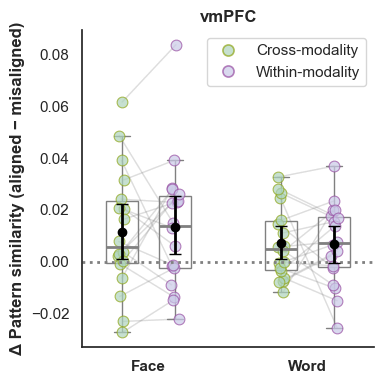

In [33]:
data_to_plot = data_all_modal[(data_all_modal['region']== 'OFC2016ConstantinescuR5') & (data_all_modal['source'] == 'Subavg') & (data_all_modal['periodicity'] == '6')]
data_to_plot['test_runs'] = data_to_plot['test_runs'].replace({'face1': 'face', 'face2': 'face', 'word1': 'word', 'word2': 'word', 'face1_face2': 'face', 'word1_word2': 'word'})
data_to_plot = data_to_plot.groupby(['subject','region','periodicity','source','cross_validation','test_runs']).agg({y_value: 'mean'}).reset_index()
data_to_plot['test_runs'] = pd.Categorical(data_to_plot['test_runs'], categories=['face','word'], ordered=True)
data_to_plot['cross_validation'] = pd.Categorical(data_to_plot['cross_validation'], categories=['xModality','xRun'], ordered=True)
stats_df = bootstrap_ci(data_to_plot, y_value, ['test_runs','cross_validation'])
print(pd.merge(stats_df, sign_flip_permutation(data_to_plot, y_value, ['periodicity', 'source', 'region','cross_validation','test_runs']), on=['test_runs','cross_validation'], how='left'))

data_to_plot_diff = data_to_plot.pivot(index=['subject', 'region', 'periodicity', 'source', 'test_runs'], columns='cross_validation', values=y_value).reset_index()
data_to_plot_diff['diff'] = data_to_plot_diff['xModality'] - data_to_plot_diff['xRun']
print(pd.merge(bootstrap_ci(data_to_plot_diff, 'diff', ['test_runs']), sign_flip_permutation(data_to_plot_diff, 'diff', ['test_runs'], alternative='two-sided'), on=['test_runs'], how='left'))

plot_subjectConnected_performance_scatter_wbox_nested(
        data_to_plot, 'test_runs','cross_validation', y_value, 'subject', stats_df=stats_df,
        outer_order=['face','word'], outer_labels=['Face','Word'],
        inner_order=['xModality','xRun'], inner_labels=['Cross-modality','Within-modality'],
        inner_colors=['#AED4BC','#CAC9E7'], inner_edgecolors=['#8EA517','#974DA2'],
        connect_subjects=True, line_alpha=0.07,
        plot_box=True, box_edgecolor='gray', box_fillcolors=None,
        plot_bar=False, errorbar_color='black',bar_width=0.25,bar_fillcolors=None,bar_edgecolors=None,
        plot_scatter=True, plot_ci=True,
        figsize=(4,4), title='vmPFC', ylabel='Δ Pattern similarity (aligned − misaligned)',
        xlabel='', yrange=None, dotted_yline=0, solid_yline=None,
        legend_loc='upper right', legend_bbox_to_anchor=(1,1),
        jitter=0.05, legend=True, legend_title=None,  ax=None,
        save = './outputs/crossmodal_contrast_values_vmpfcliterature_subavg_6fold.jpg')

r = 0.7749854504429396, p = 0.0001585432527027481


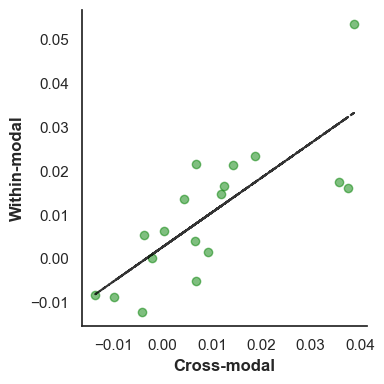

In [63]:
data_to_plot = data_all_modal[(data_all_modal['region']== 'OFC2016ConstantinescuR5') & (data_all_modal['source'] == 'Subavg') & (data_all_modal['periodicity'] == '6')]
data_to_plot['test_runs'] = data_to_plot['test_runs'].replace({'face1': 'face', 'face2': 'face', 'word1': 'word', 'word2': 'word', 'face1_face2': 'face', 'word1_word2': 'word'})
data_to_plot = data_to_plot.groupby(['subject','region','periodicity','source','cross_validation']).agg({y_value: 'mean'}).reset_index()
#data_to_plot = data_to_plot[data_to_plot['test_runs'] == 'word']
#pivot to get separate columns for cross_validation
data_to_plot = data_to_plot.pivot(index=['subject','region','periodicity','source'], columns='cross_validation', values=y_value).reset_index()
data_to_plot
plot_scatter_corr(data_to_plot['xModality'], data_to_plot['xRun'], 'Cross-modal', 'Within-modal', '',figsize=(4, 4), point_color='green',line_color='black',stats_text=False,
                  save = './outputs/crossWithinModal_contrast_values_vmpfcliterature_subavg_6fold_correlatino.jpg')


In [31]:
data_dir = './outputs/singleTrialBetaAnalysis/noICA/incl_all_subs_trials/onoffGridcontrast_multivariate/unsmoothed'
sources = ['Subavg','Subspec']
regions = ['OFC2016ConstantinescuR5']#,'vmPFCcurrentStudyR5']#['vmPFCCurrentStudy', 'OFC2016Constantinescu', 'vmPFC2016Constantinescu', 'ERC']
periodicity = [3, 4, 5, 6, 7, 8]
cross_validations = ['xModalitySingleRun','xRun']
y_value = 'contrast_value' #'beta_alignment'#'contrast_value'
filename = 'contrast_values.csv' if y_value == 'contrast_value' else 'beta_alignment_va_cat_id.csv'
data_all_modal = pd.DataFrame()
for source in sources:
    for period in periodicity:
        for cross_validation in cross_validations:
            result_dir = f'{data_dir}/{source}/periodicity{period}/{cross_validation}/phi_voxelComponentAverage/singleTrialBeta/csv/{filename}'
            df = pd.read_csv(result_dir)
            if y_value == 'beta_alignment':
                df = df.dropna()
                df['subject'] = df['subject'].astype(int)
                df['beta_alignment'] = df['beta_alignment'].astype(float)
                df['contrast_value'] = df['contrast_value'].astype(float)
            df['periodicity'] = str(period)
            df['source'] = source
            df['cross_validation'] = cross_validation
            if source == 'Subspec':
                df = df[df['subject'] != 14]
            
            data_all_modal = pd.concat([data_all_modal, df])
data_all_modal = data_all_modal[data_all_modal['region'].isin(regions)]
data_to_plot = data_all_modal[(data_all_modal['region']== 'OFC2016ConstantinescuR5') & (data_all_modal['source'] == 'Subavg') & (data_all_modal['periodicity'] == '6')]

pivoted = (data_to_plot.groupby(['subject', 'region', 'periodicity', 'source', 'test_runs', 'cross_validation'])[y_value].mean().unstack('cross_validation').reset_index())
pivoted['diff'] = pivoted['xModalitySingleRun'] - pivoted['xRun']
pivoted['test_runs'] = pivoted['test_runs'].replace({'face1': 'face', 'face2': 'face', 'word1': 'word', 'word2': 'word'})
pivoted = pivoted.groupby(['subject','region','periodicity','source','test_runs']).agg({'diff': 'mean'}).reset_index()
print('difference between cross-validation')
print(pd.merge(bootstrap_ci(pivoted, 'diff', ['test_runs']), sign_flip_permutation(pivoted, 'diff', ['test_runs'], alternative='two-sided'), on=['test_runs'], how='left'))

data_to_plot['test_runs'] = data_to_plot['test_runs'].replace({'face1': 'face', 'face2': 'face', 'word1': 'word', 'word2': 'word'})
data_to_plot = data_to_plot.groupby(['subject','region','periodicity','source','cross_validation','test_runs']).agg({y_value: 'mean'}).reset_index()
data_to_plot['test_runs'] = pd.Categorical(data_to_plot['test_runs'], categories=['face','word'], ordered=True)
data_to_plot['cross_validation'] = pd.Categorical(data_to_plot['cross_validation'], categories=['xModalitySingleRun','xRun'], ordered=True)
stats_df = bootstrap_ci(data_to_plot, y_value, ['test_runs','cross_validation'])
print(pd.merge(stats_df, sign_flip_permutation(data_to_plot, y_value, ['periodicity', 'source', 'region','cross_validation','test_runs']), on=['test_runs','cross_validation'], how='left'))


difference between cross-validation
  test_runs      mean  ci_lower  ci_upper         d  test_stat     p_val
0      face -0.007383 -0.019049  0.003938 -0.296254  -0.007383  0.238676
1      word -0.003688 -0.010335  0.003355 -0.248100  -0.003688  0.324268
  test_runs    cross_validation      mean  ci_lower  ci_upper         d  \
0      face  xModalitySingleRun  0.006181 -0.004126  0.015675  0.288135   
1      face                xRun  0.013564  0.003085  0.025343  0.563768   
2      word  xModalitySingleRun  0.003087 -0.000527  0.006893  0.385840   
3      word                xRun  0.006775 -0.000314  0.013711  0.446353   

  periodicity  source                   region  test_stat     p_val  
0           6  Subavg  OFC2016ConstantinescuR5   0.006181  0.124088  
1           6  Subavg  OFC2016ConstantinescuR5   0.013564  0.013099  
2           6  Subavg  OFC2016ConstantinescuR5   0.003087  0.061394  
3           6  Subavg  OFC2016ConstantinescuR5   0.006775  0.042196  


In [37]:
data_dir = './outputs/singleTrialBetaAnalysis/noICA/incl_all_subs_trials/onoffGridcontrast_multivariate/unsmoothed'
sources = ['Subavg','Subspec']
regions = ['OFC2016ConstantinescuR5']#,'vmPFCcurrentStudyR5']#['vmPFCCurrentStudy', 'OFC2016Constantinescu', 'vmPFC2016Constantinescu', 'ERC']
periodicity = [3, 4, 5, 6, 7, 8]
cross_validations = ['xModalitySingleRun','xRun']
y_value = 'contrast_value' #'beta_alignment'#'contrast_value'
filename = 'contrast_values.csv' if y_value == 'contrast_value' else 'beta_alignment_va_cat_id.csv'
data_all_modal = pd.DataFrame()
for source in sources:
    for period in periodicity:
        for cross_validation in cross_validations:
            result_dir = f'{data_dir}/{source}/periodicity{period}/{cross_validation}/phi_voxelComponentAverage/singleTrialBeta/csv/{filename}'
            df = pd.read_csv(result_dir)
            if y_value == 'beta_alignment':
                df = df.dropna()
                df['subject'] = df['subject'].astype(int)
                df['beta_alignment'] = df['beta_alignment'].astype(float)
                df['contrast_value'] = df['contrast_value'].astype(float)
            df['periodicity'] = str(period)
            df['source'] = source
            df['cross_validation'] = cross_validation
            if source == 'Subspec':
                df = df[df['subject'] != 14]
            
            data_all_modal = pd.concat([data_all_modal, df])
data_all_modal = data_all_modal[data_all_modal['region'].isin(regions)]

data_to_plot = data_all_modal[(data_all_modal['region']== 'OFC2016ConstantinescuR5') & (data_all_modal['source'] == 'Subavg') & (data_all_modal['periodicity'] == '6')]
data_to_plot['test_runs'] = data_to_plot['test_runs'].replace({'face1': 'face', 'face2': 'face', 'word1': 'word', 'word2': 'word'})
data_to_plot = data_to_plot.groupby(['subject','region','periodicity','source','cross_validation','test_runs']).agg({y_value: 'mean'}).reset_index()
data_to_plot['test_runs'] = pd.Categorical(data_to_plot['test_runs'], categories=['face','word'], ordered=True)
data_to_plot['cross_validation'] = pd.Categorical(data_to_plot['cross_validation'], categories=['xModalitySingleRun','xRun'], ordered=True)
stats_df = bootstrap_ci(data_to_plot, y_value, ['test_runs','cross_validation'])
print(pd.merge(stats_df, sign_flip_permutation(data_to_plot, y_value, ['periodicity', 'source', 'region','cross_validation','test_runs']), on=['test_runs','cross_validation'], how='left'))

data_to_plot_diff = data_to_plot.pivot(index=['subject', 'region', 'periodicity', 'source', 'test_runs'], columns='cross_validation', values=y_value).reset_index()
data_to_plot_diff['diff'] = data_to_plot_diff['xModalitySingleRun'] - data_to_plot_diff['xRun']
print(pd.merge(bootstrap_ci(data_to_plot_diff, 'diff', ['test_runs']), sign_flip_permutation(data_to_plot_diff, 'diff', ['test_runs'], alternative='two-sided'), on=['test_runs'], how='left'))

  test_runs    cross_validation      mean  ci_lower  ci_upper         d  \
0      face  xModalitySingleRun  0.006181 -0.004126  0.015675  0.288135   
1      face                xRun  0.013564  0.003085  0.025343  0.563768   
2      word  xModalitySingleRun  0.003087 -0.000527  0.006893  0.385840   
3      word                xRun  0.006775 -0.000314  0.013711  0.446353   

  periodicity  source                   region  test_stat     p_val  
0           6  Subavg  OFC2016ConstantinescuR5   0.006181  0.124088  
1           6  Subavg  OFC2016ConstantinescuR5   0.013564  0.013099  
2           6  Subavg  OFC2016ConstantinescuR5   0.003087  0.061394  
3           6  Subavg  OFC2016ConstantinescuR5   0.006775  0.042196  
  test_runs      mean  ci_lower  ci_upper         d  test_stat     p_val
0      face -0.007383 -0.019049  0.003938 -0.296254  -0.007383  0.238676
1      word -0.003688 -0.010335  0.003355 -0.248100  -0.003688  0.324268


#### Schematic

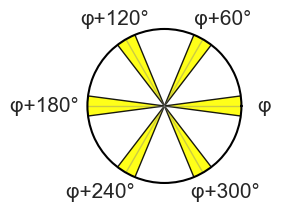

In [7]:
period = 6    
angle_range = 360 / period 
half_width = 7.5  
sns.set(style="white")
plt.rcParams["svg.fonttype"] = 'none'
plt.rcParams["font.family"] = "Arial"
plt.rcParams['font.sans-serif'] = ['Arial']
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(2, 2))

# yellow sectors 
for i in range(period):
    center = i * angle_range
    width = np.deg2rad(2 * half_width)
    ax.bar(np.deg2rad(center), 1.0, width=width,
           color="#FFFF00", alpha=0.9, edgecolor="black",
           align='center', bottom=0)

# orientation
ax.set_theta_zero_location("E")
ax.set_theta_direction(1)

# φ labels every 60°
labels = ['φ', '   φ+60°', 'φ+120°', 'φ+180°       ', 'φ+240°     ', '    φ+300°']
ax.set_xticks(np.deg2rad(np.arange(0, 360, 60)))
ax.set_xticklabels(labels, fontsize=15)
#ax.tick_params(pad=15) 
#ax.set_xticklabels('', fontsize=11)

# add radial lines 
for angle in np.deg2rad(np.arange(0, 360, 60)):
    ax.plot([angle, angle], [0, 1], color='gray', linewidth=1, alpha=0.4, zorder=1)

# remove circular grid lines but keep outer border 
ax.set_yticklabels([])
ax.grid(False)  # no circular grids
ax.spines['polar'].set_visible(True)
ax.spines['polar'].set_linewidth(1.5)
ax.spines['polar'].set_color('black')

# make bars reach the outer circle (no gap) 
ax.set_ylim(0, 0.5)
# set dpi for showing in jupyter notebook    
#plt.gcf().set_dpi(600)
#save svg
plt.savefig('./outputs/vector_plots/phi_aligned_yellow_circle_nolabels.svg', format='svg', bbox_inches='tight')
plt.show()


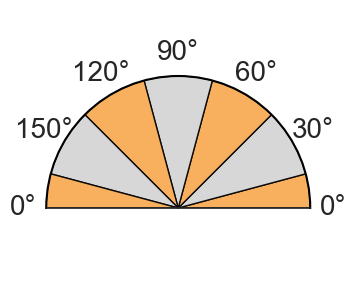

In [8]:
edges = [0, 15, 45, 75, 105, 135, 165, 180]
seg_colors = ['#f8a84d', 'lightgray', '#f8a84d', 'lightgray',
              '#f8a84d', 'lightgray', '#f8a84d']  
sns.set(style="white")
plt.rcParams["svg.fonttype"] = 'none'
plt.rcParams["font.family"] = "Arial"
plt.rcParams['font.sans-serif'] = ['Arial']
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'}, figsize=(5, 3))

ax.set_theta_zero_location("E")
ax.set_theta_direction(1)
ax.set_thetalim(0, np.pi)  # 0–180

# shading bis 
for i in range(len(seg_colors)):
    a0, a1 = edges[i], edges[i+1]          # degrees
    center = np.deg2rad((a0 + a1) / 2.0)   # radians
    width  = np.deg2rad(a1 - a0)           # radians
    ax.bar(center, 1.0, width=width, bottom=0,
           color=seg_colors[i], edgecolor='black', align='center', alpha=0.9)

#ticks
tick_degs = np.append(np.arange(0, 180, 30), 180)
tick_labels = [f"{d}°" for d in np.arange(0, 180, 30)] + ["0°"]
ax.set_xticks(np.deg2rad(tick_degs))
ax.set_xticklabels(tick_labels, fontsize=20)

#no inner circular grid lines
ax.set_yticklabels([])
ax.grid(False)
ax.spines['polar'].set_visible(True)
ax.spines['polar'].set_linewidth(1.5)
ax.spines['polar'].set_color('black')


ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('./outputs/vector_plots/bins_half_circle.svg', format='svg', bbox_inches='tight')
plt.show()



### On-off contrast MDS

In [ ]:
sources = ['Subavg','Subspec']#,'SubavgtoSubspec','SubspectoSubavg']
regions = ['OFC2016ConstantinescuR5','HC','ERC']#['vmPFCCurrentStudy', 'OFC2016Constantinescu', 'vmPFC2016Constantinescu', 'ERC']
periodicity = [3, 4, 5, 6, 7, 8]
cross_validations = ['xModalityRun', 'xModality']
y_value = 'contrast_value'#'beta_alignment'#'contrast_value'
filename = 'contrast_values.csv' if y_value == 'contrast_value' else 'beta_alignment_va_cat_id.csv'
data_all_mds = pd.DataFrame()
seeds = ['seedAvg']#['42']+[str(s) for s in list(range(1,10))]+['seedAvg']
for seed in seeds:
    data_dir = f'./outputs/singleTrialBetaAnalysis/noICA/incl_all_subs_trials/onoffGridcontrast_multivariate_mdsAlignedcosine/seed{seed}/unsmoothed'
    for source in sources:
        for period in periodicity:
            for cross_validation in cross_validations:
                result_dir = f'{data_dir}/{source}/periodicity{period}/{cross_validation}/phi_voxelComponentAverage/singleTrialBeta/csv/{filename}'
                df = pd.read_csv(result_dir)
                if y_value == 'beta_alignment':
                    df = df.dropna()
                    df['subject'] = df['subject'].astype(int)
                    df['beta_alignment'] = df['beta_alignment'].astype(float)
                    df['contrast_value'] = df['contrast_value'].astype(float)
                df = df.groupby(['subject', 'region']).agg({y_value: 'mean', 'contrast_value': 'mean'}).reset_index()
                df['periodicity'] = str(period)
                df['source'] = source
                df['cross_validation'] = cross_validation
                df['seed'] = seed
                #drop subject 14 with source is subspec
                if source == 'Subspec':
                    df = df[df['subject'] != 14]
            
                data_all_mds = pd.concat([data_all_mds, df])
#avg across seeds
data_all_mds = data_all_mds.groupby(['subject', 'region', 'periodicity', 'source','cross_validation']).agg({y_value: 'mean'}).reset_index()
data_all_mds = data_all_mds[data_all_mds['region'].isin(regions)]
#data_all_mds['region'] = pd.Categorical(data_all_mds['region'], categories=regions, ordered=True)

print(pd.merge(bootstrap_ci(data_all_mds[data_all_mds['region'].isin(regions)], y_value, ['periodicity', 'source', 'region']),
               sign_flip_permutation(data_all_mds[data_all_mds['region'].isin(regions)], y_value, ['periodicity', 'source', 'region']),
               on=['periodicity', 'source', 'region'], how='left').to_string(max_rows=None, max_cols=None))
data_avg = data_all_mds.groupby(['subject', 'region', 'periodicity', 'source']).agg({y_value: 'mean'}).reset_index()
diff_data_mds = pd.DataFrame()
diffavg_data_mds = pd.DataFrame()
for region in regions:
    for source in sources:
        data_avg_region_source = data_avg[(data_avg['region'] == region) & (data_avg['source'] == source)]
        data_avg_region_source_periodicity6 = data_avg_region_source[data_avg_region_source['periodicity'] == '6']
        data_avg_region_source_periodicity6_other = data_avg_region_source[data_avg_region_source['periodicity'] != '6']
        for period in data_avg_region_source_periodicity6_other['periodicity'].unique():
            data_avg_region_source_periodicity6_other_period = data_avg_region_source_periodicity6_other[data_avg_region_source_periodicity6_other['periodicity'] == period]
            # print(region, source, period)
            # print(stats.ttest_rel(data_avg_region_source_periodicity6[y_value], data_avg_region_source_periodicity6_other_period[y_value]))
            merged_df = pd.merge(data_avg_region_source_periodicity6[['subject', y_value]],data_avg_region_source_periodicity6_other_period[['subject', y_value]],on='subject',suffixes=('_6', f'_{period}'))
            diff_data_mds = pd.concat([diff_data_mds, pd.DataFrame({'region': region,'source': source,'periodicity': period,'diff': merged_df[f'{y_value}_6'] - merged_df[f'{y_value}_{period}']})], ignore_index=True)
        other_avg = (data_avg_region_source_periodicity6_other.groupby('subject', as_index=False)[y_value].mean().rename(columns={y_value: f'{y_value}_otherMean'}))
        merged_df = pd.merge(data_avg_region_source_periodicity6[['subject', y_value]].rename(columns={y_value: f'{y_value}_6'}),other_avg,on='subject')
        diffavg_data_mds = pd.concat([diffavg_data_mds, pd.DataFrame({'region': region,'source': source,'periodicity': 'mean_other','diff': merged_df[f'{y_value}_6'] - merged_df[f'{y_value}_otherMean']})], ignore_index=True)
#print('6-fold vs other folds')           
#print(pd.merge(bootstrap_ci(diff_data_mds, 'diff', ['region', 'source', 'periodicity']),sign_flip_permutation(diff_data_mds, 'diff', ['region', 'source', 'periodicity']),on=['region', 'source', 'periodicity'], how='left').to_string(max_rows=None, max_cols=None))
print('6-fold vs average of other folds')           
print(pd.merge(bootstrap_ci(diffavg_data_mds, 'diff', ['region', 'source', 'periodicity']),
               sign_flip_permutation(diffavg_data_mds, 'diff', ['region', 'source', 'periodicity']),
               on=['region', 'source', 'periodicity'], how='left').to_string(max_rows=None, max_cols=None))

#### vmPFC all folds

In [63]:
print('6-fold in vmPFC')
print(pd.merge(bootstrap_ci(data_all_mds[(data_all_mds['region'].isin(['OFC2016ConstantinescuR5'])) & (data_all_mds['periodicity'] == '6')], y_value, ['periodicity', 'source', 'region']),
               sign_flip_permutation(data_all_mds[(data_all_mds['region'].isin(['OFC2016ConstantinescuR5']))& (data_all_mds['periodicity'] == '6')], y_value, ['periodicity', 'source', 'region'], report_bonferroni=True),
               on=['periodicity', 'source', 'region'], how='left').to_string(max_rows=None, max_cols=None))
print('6-fold vs average of other folds in vmPFC')
print(pd.merge(bootstrap_ci(diffavg_data_mds[(diffavg_data_mds['region'].isin(['OFC2016ConstantinescuR5', 'ERC', 'HC']))], 'diff', ['region', 'source', 'periodicity']),
               sign_flip_permutation(diffavg_data_mds[(diffavg_data_mds['region'].isin(['OFC2016ConstantinescuR5', 'ERC', 'HC']))], 'diff', ['region', 'source', 'periodicity']),
               on=['region', 'source', 'periodicity'], how='left').drop(columns=['test_stat']).to_string(max_rows=None, max_cols=None))

6-fold in vmPFC
  periodicity   source                   region      mean  ci_lower  ci_upper         d  test_stat     p_val  bonferroni_p_val
0           6   Subavg  OFC2016ConstantinescuR5  0.005108  0.000884  0.009668  0.381002   0.005108  0.015498          0.030997
1           6  Subspec  OFC2016ConstantinescuR5  0.002740 -0.001207  0.006607  0.237118   0.002740  0.089691          0.179382
6-fold vs average of other folds in vmPFC
                    region   source periodicity      mean  ci_lower  ci_upper         d     p_val
0                      ERC   Subavg  mean_other  0.003041  0.000108  0.006317  0.460602  0.036296
1                      ERC  Subspec  mean_other  0.003408 -0.000912  0.008172  0.360471  0.085991
2                       HC   Subavg  mean_other  0.002363 -0.000107  0.005022  0.424606  0.042996
3                       HC  Subspec  mean_other  0.000354 -0.001765  0.002456  0.079189  0.376062
4  OFC2016ConstantinescuR5   Subavg  mean_other  0.004883  0.000502  0.

In [25]:
print('Effect of control folds')
print(pd.merge(bootstrap_ci(data_all_mds[(data_all_mds['region'].isin(['OFC2016ConstantinescuR5'])  & (data_all_mds['periodicity'] != '6'))], y_value, ['periodicity', 'source', 'region']),
               sign_flip_permutation(data_all_mds[(data_all_mds['region'].isin(['OFC2016ConstantinescuR5']) & (data_all_mds['periodicity'] != '6'))], y_value, ['periodicity', 'source', 'region']),
               on=['periodicity', 'source', 'region'], how='left').to_string(max_rows=None, max_cols=None))
print('Difference between 6-fold and other folds')
print(pd.merge(bootstrap_ci(diff_data_mds[diff_data_mds['region'].isin(['OFC2016ConstantinescuR5'])], 'diff', ['region', 'source', 'periodicity']),
               sign_flip_permutation(diff_data_mds[diff_data_mds['region'].isin(['OFC2016ConstantinescuR5'])], 'diff', ['region', 'source', 'periodicity']),
               on=['region', 'source', 'periodicity'], how='left').drop(columns=['test_stat']).to_string(max_rows=None, max_cols=None))
print(pd.merge(bootstrap_ci(diffavg_data_mds[diffavg_data_mds['region'].isin(['OFC2016ConstantinescuR5'])], 'diff', ['region', 'source', 'periodicity']),
               sign_flip_permutation(diffavg_data_mds[diffavg_data_mds['region'].isin(['OFC2016ConstantinescuR5'])], 'diff', ['region', 'source', 'periodicity']),
               on=['region', 'source', 'periodicity'], how='left').drop(columns=['test_stat']).to_string(max_rows=None, max_cols=None))

Effect of control folds
  periodicity   source                   region      mean  ci_lower  ci_upper         d  test_stat     p_val
0           3   Subavg  OFC2016ConstantinescuR5  0.001317 -0.001463  0.004202  0.152084   0.001317  0.189681
1           3  Subspec  OFC2016ConstantinescuR5  0.001504 -0.002236  0.005932  0.124564   0.001504  0.254175
2           4   Subavg  OFC2016ConstantinescuR5 -0.000098 -0.003850  0.003549 -0.008671  -0.000098  0.519948
3           4  Subspec  OFC2016ConstantinescuR5  0.002030 -0.001040  0.005194  0.220087   0.002030  0.106389
4           5   Subavg  OFC2016ConstantinescuR5  0.000177 -0.002077  0.002514  0.025192   0.000177  0.444056
5           5  Subspec  OFC2016ConstantinescuR5 -0.000535 -0.003590  0.002465 -0.059955  -0.000535  0.634737
6           7   Subavg  OFC2016ConstantinescuR5 -0.002850 -0.005727  0.000035 -0.319681  -0.002850  0.969303
7           7  Subspec  OFC2016ConstantinescuR5  0.000097 -0.003813  0.004143  0.008210   0.000097  0.48

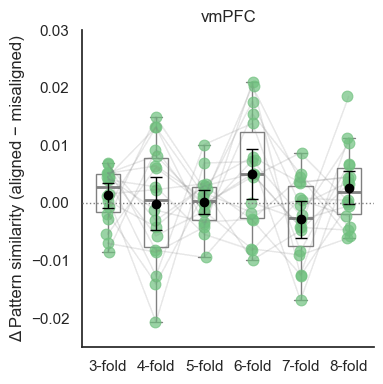

In [5]:
for reg, reg_name,color,file in zip(['OFC2016ConstantinescuR5'],['vmPFC'],['#70c17f'], ['literature']):
    data_to_plot = data_all_mds[(data_all_mds['source'] == 'Subavg') & (data_all_mds['region'].isin([reg]))]# & (data_all_mds['periodicity'] != '6')]
    data_to_plot = data_to_plot.groupby(['subject', 'region', 'periodicity', 'source']).agg({y_value: 'mean'}).reset_index()
    data_to_plot['periodicity'] = pd.Categorical(data_to_plot['periodicity'], categories=['3','4','5','6','7','8',], ordered=True)
    stats_df_to_plot = bootstrap_ci(data_to_plot, target_col=y_value, group_vars=['periodicity'])

    plot_subjectConnected_performance_scatter_wbox(data_to_plot, 'periodicity', y_value, 'subject', stats_df_to_plot,
                                                    title=reg_name,
                                                    condition_order=['3','4','5','6','7','8'], 
                                                    condition_labels=['3-fold','4-fold','5-fold','6-fold','7-fold','8-fold'],
                                                    fill_colors=[color]*6, #['#70c17f','#33CC99','#7ca9cc','#F4A9A7'], #FE8D01'
                                                    #edge_colors=['#FE8D01','#F4A9A7','#7ca9cc','#70c17f'], 
                                                    connect_subjects=True, line_alpha=0.03,
                                                    plot_box=True,plot_bar=False,box_edgecolor='gray',errorbar_color='black',
                                                    figsize=(4,4), 
                                                    ylabel='Δ Pattern similarity (aligned − misaligned)', 
                                                    xlabel='', dotted_yline=0, jitter=0.02, ax=None,
                                                    yrange=(-0.025, 0.03),
                                                    save_svg=True,
                                                   save = f'./outputs/vector_plots/contrast_values_vmpfc{file}_subavg_controlfolds_mds.svg')

#### Bins

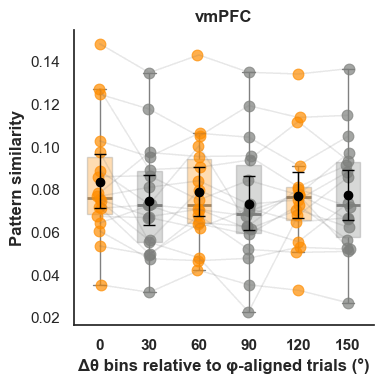

In [65]:
cross_validations = ['xModalityRun', 'xModality']#,'xRun']
data_all_mds = pd.DataFrame()
for cross_validation in cross_validations:
    bin_values = pd.read_csv(f'./outputs/singleTrialBetaAnalysis/noICA/incl_all_subs_trials/onoffGridcontrast_multivariate_mdsAlignedcosine/seedseedAvg/unsmoothed/Subavg/periodicity6/{cross_validation}/phi_voxelComponentAverage/singleTrialBeta/csv/bin_means.csv')
    bin_values = bin_values.groupby(['bin_centers', 'subject', 'region']).agg({'bin_means': 'mean'}).reset_index()
    bin_values['cross_validation'] = cross_validation
    data_all_mds = pd.concat([data_all_mds, bin_values])

for reg, reg_name, file in zip(['OFC2016ConstantinescuR5'],['vmPFC'],['literature']):
    region = [reg]#'vmPFCcurrentStudyR5']#['OFC2016ConstantinescuR5']#, 'OFC2016Constantinescu']#,'vmPFCCurrentStudy', 'OFC2016Constantinescu', 'vmPFC2016Constantinescu']
    bin_values = data_all_mds[data_all_mds['region'].isin(region)]
    bin_values = bin_values.groupby(['bin_centers', 'subject', 'region']).agg({'bin_means': 'mean'}).reset_index()
    bin_order =  bin_values['bin_centers'].unique()#[0, 30, 60, 90, 120, 150]
    bin_values['bin_centers'] = pd.Categorical(bin_values['bin_centers'], categories=bin_order, ordered=True)
    stats_df_to_plot = bootstrap_ci(bin_values, target_col='bin_means', group_vars=['bin_centers'])

    plot_subjectConnected_performance_scatter_wbox(bin_values, 'bin_centers', 'bin_means', 'subject',stats_df_to_plot,
                                            title=reg_name,
                                            condition_order=bin_order, 
                                            condition_labels=bin_order,plot_scatter=True,
                                            fill_colors=['#FE8D01', '#7d7f7c','#FE8D01', '#7d7f7c','#FE8D01', '#7d7f7c'], #FE8D01'
                                            #edge_colors=['#FE8D01','#F4A9A7','#7ca9cc','#70c17f'], 
                                            connect_subjects=True, line_alpha=0.03,
                                            plot_box=True,plot_bar=False,box_edgecolor='gray',errorbar_color='black',box_fillcolors=['#FE8D01', '#7d7f7c','#FE8D01', '#7d7f7c','#FE8D01', '#7d7f7c'],
                                            figsize=(4,4),
                                            ylabel='Pattern similarity', 
                                            xlabel='Δθ bins relative to φ-aligned trials (°)', yrange=None, jitter=0.02, ax=None,
                                            save = f'./outputs/vmPFC{file}_bin_means_mds.jpg')

  periodicity  source                   region      mean  ci_lower  ci_upper         d  test_stat   p_val
0           6  Subavg  OFC2016ConstantinescuR5  0.004945  0.000647  0.009419  0.524416   0.004945  0.0224
1           6  Subavg                       HC  0.002288  0.000187  0.004675  0.469092   0.002288  0.0292
2           6  Subavg                      ERC  0.002398 -0.000050  0.005111  0.427995   0.002398  0.0461


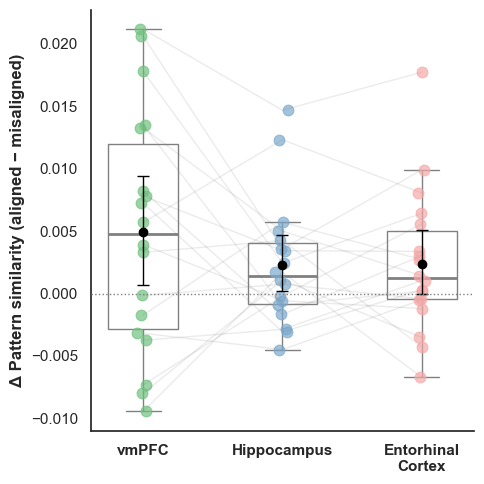

In [149]:
data_to_plot = data_all_mds[(data_all_mds['periodicity'] == '6') & (data_all_mds['region'].isin(regions)) & (data_all_mds['source'].isin(['Subavg']))]
data_to_plot['region'] = pd.Categorical(data_to_plot['region'], categories=regions, ordered=True)
data_to_plot = data_to_plot.groupby(['subject', 'region', 'periodicity', 'source']).agg({y_value: 'mean'}).reset_index()
stats_df = bootstrap_ci(data_to_plot, target_col=y_value, group_vars=['periodicity', 'source','region'])
print(stats_df
    .merge(sign_flip_permutation(data_to_plot, y_value, ['periodicity', 'source', 'region']), on=['periodicity', 'source', 'region'], how='left')
    .to_string(max_rows=None, max_cols=None))


plot_subjectConnected_performance_scatter_wbox(data_to_plot, 'region', y_value, 'subject', stats_df,
                                                condition_order=regions, 
                                                condition_labels=['vmPFC','Hippocampus','Entorhinal\nCortex'],
                                                fill_colors=['#70c17f','#7ca9cc','#F4A9A7'], #FE8D01'
                                                #edge_colors=['#FE8D01','#F4A9A7','#7ca9cc','#70c17f'], 
                                                connect_subjects=True, line_alpha=0.05,
                                                plot_box=True,plot_bar=False,box_edgecolor='gray',errorbar_color='black',
                                                figsize=(5,5), title=None, 
                                                ylabel='Δ Pattern similarity (aligned − misaligned)', 
                                                xlabel='', yrange=None, dotted_yline=0, jitter=0.02, ax=None)#,
                                                #save = './outputs/contrast_values_vmpfchcerc_subavg_6fold.jpg')

### On-off contrast with distance

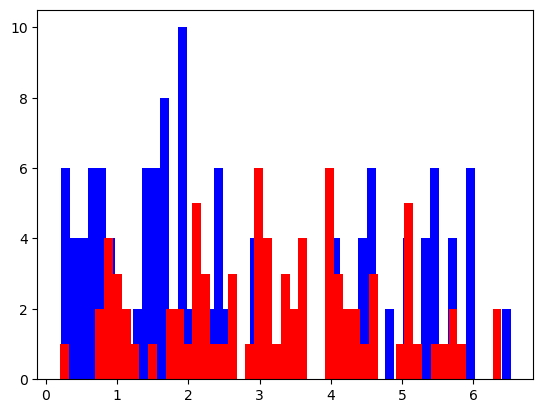

TtestResult(statistic=array([-1.94728122]), pvalue=array([0.05286023]), df=array([206.]))
w_dist: mean=2.719462373158368, median=1.9520842199197599, range=0.214526528972404 - 6.52579940104604
f_dist: mean=3.2029298639898474, median=3.131208004792555, range=0.200619745983847 - 6.39330357816416
w_dist: Q1=1.31554439164454, Q2=1.9520842199197599, Q3=4.57829283679829, Q4=6.52579940104604
f_dist: Q1=2.1133574368007273, Q2=3.131208004792555, Q3=4.2389631701986, Q4=6.39330357816416
wf_dist: Q1=1.47889776428278, Q2=2.5595461625887, Q3=4.48345266169621, Q4=6.52579940104604


In [ ]:
w_dist = pd.read_csv('./outputs/euclideanDistance_Subavg_w1_w2.csv', header=None)
f_dist = pd.read_csv('./outputs/euclideanDistance_Subavg_f1_f2.csv', header=None)
#plot distrubution of w_dist and f_dist
plt.hist(w_dist, bins=50,color='blue')
plt.hist(f_dist, bins=50,color='red')
plt.show()
#compare if the two distributions are significantly different
print(stats.ttest_ind(w_dist, f_dist))
#print mean, median, range for w_dist and f_dist
print(f'w_dist: mean={np.mean(w_dist)}, median={np.median(w_dist)}, range={np.min(w_dist)} - {np.max(w_dist)}')
print(f'f_dist: mean={np.mean(f_dist)}, median={np.median(f_dist)}, range={np.min(f_dist)} - {np.max(f_dist)}')
#get ranges for quartiles
print(f'w_dist: Q1={np.percentile(w_dist, 25)}, Q2={np.percentile(w_dist, 50)}, Q3={np.percentile(w_dist, 75)}, Q4={np.percentile(w_dist, 100)}')
print(f'f_dist: Q1={np.percentile(f_dist, 25)}, Q2={np.percentile(f_dist, 50)}, Q3={np.percentile(f_dist, 75)}, Q4={np.percentile(f_dist, 100)}')
wf_dist = pd.concat([w_dist, f_dist], axis=0)
#range of quartiles
print(f'wf_dist: Q1={np.percentile(wf_dist, 25)}, Q2={np.percentile(wf_dist, 50)}, Q3={np.percentile(wf_dist, 75)}, Q4={np.percentile(wf_dist, 100)}')



In [8]:
data_dir = './outputs/singleTrialBetaAnalysis/noICA/incl_all_subs_trials/onoffGridcontrast_multivariate/unsmoothed'
sources = ['Subavg']#,'Subspec']#,'SubavgtoSubspec','SubspectoSubavg']
regions = ['OFC2016ConstantinescuR5']#,'vmPFCcurrentStudyR5','HC','ERC']#['vmPFCCurrentStudy', 'OFC2016Constantinescu', 'vmPFC2016Constantinescu', 'ERC']
periodicity = [3, 4, 5, 6, 7, 8]
cross_validations = ['xModalityRun', 'xModality']
y_value = 'corr' 
filename = 'pattern_similarity_wDistance.csv'
distance_type = 'va'
data_all = pd.DataFrame()
for source in sources:
    for period in periodicity:
        for cross_validation in cross_validations:
            result_dir = f'{data_dir}/{source}/periodicity{period}/{cross_validation}/phi_voxelComponentAverage/singleTrialBeta/csv/{filename}'
            df = pd.read_csv(result_dir)
            df = df[df['region'].isin(regions)]
            df['periodicity'] = str(period)
            df['source'] = source
            df['cross_validation'] = cross_validation
            #drop subject 14 with source is subspec
            if source == 'Subspec':
                df = df[df['subject'] != 14]
            
            data_all = pd.concat([data_all, df])
#subset to phi_aligned_consistency and other_consistency both being 1
#data_all = data_all[(data_all['phi_aligned_consistency'] != 0) | (data_all['other_consistency'] != 0)]

    consistency periodicity      mean  ci_lower  ci_upper         d  test_stat     p_val
0             0           3 -0.005583 -0.009206 -0.001575 -0.680963  -0.005583  0.992701
1             0           4 -0.004727 -0.008950 -0.000462 -0.509395  -0.004727  0.972203
2             0           5 -0.001848 -0.004736  0.001186 -0.286543  -0.001848  0.878712
3             0           6  0.005080  0.001941  0.008204  0.747371   0.005080  0.004100
4             0           7 -0.001825 -0.004526  0.000942 -0.307447  -0.001825  0.889611
5             0           8 -0.001843 -0.005379  0.001734 -0.240815  -0.001843  0.832117
6             1           3 -0.003302 -0.008100  0.001608 -0.313421  -0.003302  0.894411
7             1           4 -0.000783 -0.007123  0.006195 -0.054339  -0.000783  0.591241
8             1           5 -0.004515 -0.008656 -0.000454 -0.504042  -0.004515  0.971903
9             1           6  0.010011  0.002614  0.017997  0.606050   0.010011  0.010099
10            1      

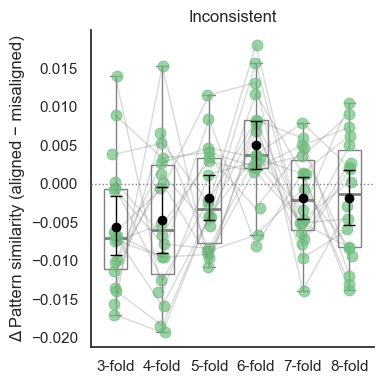

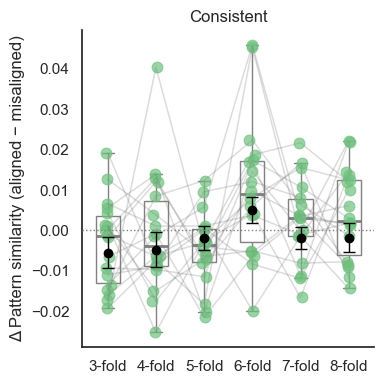

In [9]:
data_all['consistency'] = data_all['phi_aligned_consistency'] * data_all['other_consistency']
def contrast(group):
    aligned = group[group["alignment_label"] == 1]["corr"].mean()
    misaligned = group[group["alignment_label"] == 0]["corr"].mean()
    return aligned - misaligned
data_to_plot = data_all.copy()
data_to_plot = (data_to_plot.groupby(["subject", "test_runs", "consistency","periodicity"]).apply(contrast).reset_index(name="aligned_minus_misaligned"))
data_to_plot = data_to_plot.groupby(['subject', 'consistency','periodicity']).agg({'aligned_minus_misaligned': 'mean'}).reset_index()
stats_df_to_plot = bootstrap_ci(data_to_plot, 'aligned_minus_misaligned', ['consistency','periodicity'])
print(stats_df_to_plot.merge(sign_flip_permutation(data_to_plot, 'aligned_minus_misaligned', ['consistency','periodicity']), on=['consistency','periodicity'], how='left').to_string(max_rows=None, max_cols=None))
#get difference between 0 and 1
# Compute difference (consistency=1 minus consistency=0) for each subject and periodicity
pivoted = data_to_plot.pivot(index="subject", columns=["consistency","periodicity"], values="aligned_minus_misaligned")
diffs = pivoted.xs(1, level="consistency", axis=1) - pivoted.xs(0, level="consistency", axis=1)
diffs = diffs.reset_index().melt(id_vars="subject", var_name="periodicity", value_name="diff_value")
diffs["periodicity"] = diffs["periodicity"].astype(str)
print('difference across consistency')
print(pd.merge(bootstrap_ci(diffs, 'diff_value', ['periodicity']),sign_flip_permutation(diffs, 'diff_value', ['periodicity']),on=['periodicity'], how='left').to_string(max_rows=None, max_cols=None))
for consis,consis_name in zip([0,1],['Inconsistent','Consistent']):
    data_to_plot_consis = data_to_plot[data_to_plot['consistency'] == consis]
    plot_subjectConnected_performance_scatter_wbox(data_to_plot_consis, 'periodicity', 'aligned_minus_misaligned', 'subject', stats_df_to_plot,
                                                condition_order=['3','4','5','6','7','8'], 
                                                condition_labels=['3-fold','4-fold','5-fold','6-fold','7-fold','8-fold'],#['vmPFC\n(literature)','vmPFC\n(this study)','Hippocampus','Entorhinal\nCortex'],
                                                fill_colors=['#70c17f']*6,#['#70c17f']*4,#['#7ca9cc']*4
                                                edge_colors=['#70c17f']*6,#['#70c17f']*4,#['#7ca9cc']*4, 
                                                connect_subjects=True, line_alpha=0.05,
                                                plot_box=True,plot_bar=False,box_edgecolor='gray',errorbar_color='black',
                                                figsize=(4,4), title=consis_name, 
                                                ylabel='Δ Pattern similarity (aligned − misaligned)', 
                                                xlabel='', #yrange=(0.35,0.85),#(1, 3.5), 
                                                dotted_yline=0, jitter=0.03, ax=None,
                                                connect_errorbar_means=False)#,


In [19]:
data_all['consistency'] = data_all['phi_aligned_consistency'] * data_all['other_consistency']
def contrast(group):
    aligned = group[group["alignment_label"] == 1]["corr"].mean()
    misaligned = group[group["alignment_label"] == 0]["corr"].mean()
    return aligned - misaligned
data_to_plot = data_all[data_all['periodicity'] == '6']
data_to_plot['consistency'] = data_to_plot['consistency'].astype(str)
data_to_plot = (data_to_plot.groupby(["subject", "test_runs", "consistency"]).apply(contrast).reset_index(name="aligned_minus_misaligned"))
data_to_plot = data_to_plot.groupby(['subject', 'consistency']).agg({'aligned_minus_misaligned': 'mean'}).reset_index()
stats_df_to_plot = bootstrap_ci(data_to_plot, 'aligned_minus_misaligned', ['consistency'])
print(stats_df_to_plot.merge(sign_flip_permutation(data_to_plot, 'aligned_minus_misaligned', ['consistency']), on=['consistency'], how='left').to_string(max_rows=None, max_cols=None))

  consistency      mean  ci_lower  ci_upper         d  test_stat     p_val
0           0  0.005080  0.001922  0.008240  0.739041   0.005080  0.004100
1           1  0.010011  0.002549  0.017815  0.601949   0.010011  0.010099


Number of trials for each consistency level:
consistency
0    204489
1    103859
  consistency      mean  ci_lower  ci_upper         d  test_stat     p_val
0           0  0.005080  0.001922  0.008240  0.739041   0.005080  0.004100
1           1  0.010011  0.002549  0.017815  0.601949   0.010011  0.010099
difference across consistency for each subject
  group      mean  ci_lower  ci_upper         d  test_stat     p_val
0   grp  0.004931 -0.003106   0.01262  0.288011   0.004931  0.121988


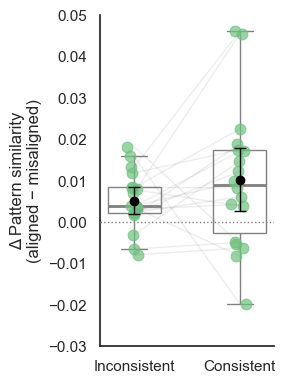

In [34]:
data_all['consistency'] = data_all['phi_aligned_consistency'] * data_all['other_consistency']
def contrast(group):
    aligned = group[group["alignment_label"] == 1]["corr"].mean()
    misaligned = group[group["alignment_label"] == 0]["corr"].mean()
    return aligned - misaligned
data_to_plot = data_all[data_all['periodicity'] == '6']
data_to_plot['consistency'] = data_to_plot['consistency'].astype(str)
# print number of trials for each consistency level
print("Number of trials for each consistency level:")
print(data_to_plot.groupby("consistency").size().to_string())
data_to_plot = (data_to_plot.groupby(["subject", "test_runs", "consistency"]).apply(contrast).reset_index(name="aligned_minus_misaligned"))
data_to_plot = data_to_plot.groupby(['subject', 'consistency']).agg({'aligned_minus_misaligned': 'mean'}).reset_index()
stats_df_to_plot = bootstrap_ci(data_to_plot, 'aligned_minus_misaligned', ['consistency'])
print(stats_df_to_plot.merge(sign_flip_permutation(data_to_plot, 'aligned_minus_misaligned', ['consistency']), on=['consistency'], how='left').to_string(max_rows=None, max_cols=None))

diffs = (data_to_plot.pivot(index="subject", columns=["consistency"], values="aligned_minus_misaligned").assign(diff_value=lambda df: df['1'] - df['0']))
print('difference across consistency for each subject')
diffs['group'] = 'grp'
print(pd.merge(bootstrap_ci(diffs, 'diff_value', ['group']),sign_flip_permutation(diffs, 'diff_value', ['group']),on=['group'], how='left').to_string(max_rows=None, max_cols=None))

plot_subjectConnected_performance_scatter_wbox(data_to_plot, 'consistency', 'aligned_minus_misaligned', 'subject', stats_df_to_plot,
                                            condition_order=['0', '1'], 
                                            condition_labels=['Inconsistent','Consistent'],#['vmPFC\n(literature)','vmPFC\n(this study)','Hippocampus','Entorhinal\nCortex'],
                                            fill_colors=['#70c17f']*2,#['#70c17f']*4,#['#7ca9cc']*4
                                            edge_colors=['#70c17f']*2,#['#70c17f']*4,#['#7ca9cc']*4, 
                                            connect_subjects=True, line_alpha=0.07,
                                            plot_box=True,plot_bar=False,box_edgecolor='gray',errorbar_color='black',
                                            figsize=(3,4), title='', 
                                            ylabel='Δ Pattern similarity\n(aligned − misaligned)', 
                                            xlabel='', #yrange=(0.35,0.85),#(1, 3.5), 
                                            dotted_yline=0, jitter=0.03, ax=None,
                                            connect_errorbar_means=False, density_scaled_jitter=False,
                                            yrange=(-0.03,0.05),
                                            save_svg=True,
                                            save = './outputs/vector_plots/6fold_by_2consistency_vmpfc.svg')

In [10]:
col_t = f"phi_aligned_{distance_type}"
col_j = f"other_{distance_type}"
all_distances = pd.concat([data_all[col_t], data_all[col_j]], axis=0)
quantiles = pd.qcut(all_distances, 4, retbins=True)[1]
labels = ["Q1", "Q2", "Q3", "Q4"]
data_all["quartile_t"] = pd.cut(data_all[col_t], bins=quantiles,labels=labels, include_lowest=True)
data_all["quartile_j"] = pd.cut(data_all[col_j], bins=quantiles,labels=labels, include_lowest=True)


df_samequart = data_all[data_all["quartile_t"] == data_all["quartile_j"]].copy()
pairs_per_subject_quartile = (df_samequart.groupby(["subject", "quartile_t", "test_runs"]).size().reset_index(name="n_pairs"))
print("\nPairs per subject, quartile, and test_run:")
#print(pairs_per_subject_quartile.to_string(max_rows=None, max_cols=None))
print(pairs_per_subject_quartile.groupby(["quartile_t"]).agg({'n_pairs': 'mean'}).to_string(max_rows=None, max_cols=None))

def contrast(group):
    aligned = group[group["alignment_label"] == 1]["corr"].mean()
    misaligned = group[group["alignment_label"] == 0]["corr"].mean()
    return aligned - misaligned

contrast_df = (df_samequart.groupby(["subject", "quartile_t", "test_runs"]).apply(contrast).reset_index(name="aligned_minus_misaligned").rename(columns={"quartile_t": "quartile"}))
#average across test runs
contrast_df = contrast_df.groupby(["subject", "quartile"]).agg({'aligned_minus_misaligned': 'mean'}).reset_index()


Pairs per subject, quartile, and test_run:
                n_pairs
quartile_t             
Q1          1043.796296
Q2           991.203704
Q3          1137.175926
Q4           960.212963


In [26]:
import statsmodels.formula.api as smf
col_t = f"phi_aligned_{distance_type}"
col_j = f"other_{distance_type}"
model_estimates = pd.DataFrame()
for subject in data_all['subject'].unique():
    subj_data = data_all[(data_all['subject'] == subject) & (data_all['periodicity'] == '6')]
    subj_data['distance_sum'] = subj_data[col_t] + subj_data[col_j]
    #corr ~ alignment + distance_sum + interaction
    model = smf.ols('corr ~ alignment_label + distance_sum + alignment_label:distance_sum', data=subj_data).fit()
    model_estimates = pd.concat([model_estimates, pd.DataFrame({'subject': subject, 'alignment_beta': model.params['alignment_label'], 
                                                               'distance_sum_beta': model.params['distance_sum'], 'interaction_beta': model.params['alignment_label:distance_sum']
                                                                }, 
                                                                index=[0])])
#melt to long format
model_estimates = model_estimates.melt(id_vars='subject', var_name='parameter', value_name='estimate')
print(pd.merge(bootstrap_ci(model_estimates, 'estimate', ['parameter']),sign_flip_permutation(model_estimates, 'estimate', ['parameter']),on=['parameter'], how='left').to_string(max_rows=None, max_cols=None))

           parameter      mean  ci_lower  ci_upper         d  test_stat     p_val
0     alignment_beta  0.005667  0.002547  0.009056  0.794831   0.005667  0.000900
1  distance_sum_beta -0.000479 -0.002090  0.001029 -0.141389  -0.000479  0.710329
2   interaction_beta -0.000606 -0.001799  0.000531 -0.238372  -0.000606  0.832717


  quartile      mean  ci_lower  ci_upper         d  test_stat     p_val
0       Q1  0.010540  0.003798  0.016720  0.745759   0.010540  0.003100
1       Q2  0.004968 -0.000733  0.010929  0.394112   0.004968  0.059994
2       Q3  0.003305 -0.002012  0.008400  0.293956   0.003305  0.112789
3       Q4  0.007934  0.001872  0.014285  0.590438   0.007934  0.011099
        group      mean  ci_lower  ci_upper         d  test_stat     p_val
0  diff_Q2_Q1 -0.005571 -0.013381  0.002116 -0.332252  -0.005571  0.190481
1  diff_Q3_Q1 -0.007235 -0.015516  0.001594 -0.390687  -0.007235  0.123588
2  diff_Q3_Q2 -0.001663 -0.009788  0.006682 -0.093075  -0.001663  0.707629
3  diff_Q4_Q1 -0.002606 -0.011224  0.006155 -0.137076  -0.002606  0.575342
4  diff_Q4_Q2  0.002966 -0.002512  0.008193  0.255202   0.002966  0.297170
5  diff_Q4_Q3  0.004629 -0.003466  0.012391  0.268662   0.004629  0.273573


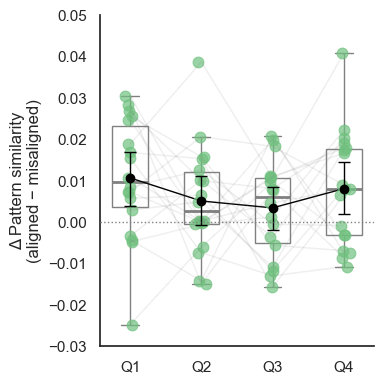

In [36]:
data_to_plot = data_all[data_all['periodicity'] == '6']
distance_type = 'va'
col_t = f"phi_aligned_{distance_type}"
col_j = f"other_{distance_type}"
data_to_plot['distance_sum'] = (data_to_plot[col_t] + data_to_plot[col_j])
data_to_plot['quartile'] = None
for subject in data_to_plot['subject'].unique():
    subj_data = data_to_plot[data_to_plot['subject'] == subject]
    for test_run in subj_data['test_runs'].unique():
        run_data = subj_data[subj_data['test_runs'] == test_run]
        run_data['quartile'] = pd.qcut(run_data['distance_sum'], 4, labels=['Q1','Q2','Q3','Q4'])
        data_to_plot.loc[(data_to_plot['subject'] == subject) & (data_to_plot['test_runs'] == test_run), 'quartile'] = run_data['quartile']


def contrast(group):
    aligned = group[group["alignment_label"] == 1]["corr"].mean()
    misaligned = group[group["alignment_label"] == 0]["corr"].mean()
    return aligned - misaligned

data_to_plot = (data_to_plot.groupby(["subject", "quartile","test_runs"]).apply(contrast).reset_index(name="aligned_minus_misaligned"))
#average across test runs
data_to_plot = data_to_plot.groupby(["subject", "quartile"]).agg({'aligned_minus_misaligned': 'mean'}).reset_index()

stats_df_to_plot = bootstrap_ci(data_to_plot, 'aligned_minus_misaligned', ['quartile'])
print(stats_df_to_plot.merge(sign_flip_permutation(data_to_plot, 'aligned_minus_misaligned', ['quartile']), on=['quartile'], how='left').to_string(max_rows=None, max_cols=None))
# get difference between Q1 and Q2 for each subject
# Compute all pairwise quartile differences per subject, concisely
diffs = (data_to_plot.pivot(index="subject", columns=["quartile"], values="aligned_minus_misaligned").assign(diff_Q2_Q1=lambda df: df['Q2'] - df['Q1'], diff_Q3_Q1=lambda df: df['Q3'] - df['Q1'], diff_Q4_Q1=lambda df: df['Q4'] - df['Q1'], diff_Q4_Q2=lambda df: df['Q4'] - df['Q2'], diff_Q3_Q2=lambda df: df['Q3'] - df['Q2'], diff_Q4_Q3=lambda df: df['Q4'] - df['Q3']))
diffs = diffs.reset_index()[['subject','diff_Q2_Q1','diff_Q3_Q1','diff_Q4_Q1','diff_Q4_Q2','diff_Q3_Q2','diff_Q4_Q3']].melt(id_vars='subject', value_vars=['diff_Q2_Q1','diff_Q3_Q1','diff_Q4_Q1','diff_Q4_Q2','diff_Q3_Q2','diff_Q4_Q3'], var_name='group', value_name='diff_value')
print(pd.merge(bootstrap_ci(diffs, 'diff_value', ['group']),sign_flip_permutation(diffs, 'diff_value', ['group'],alternative='two-sided'),on=['group'], how='left').to_string(max_rows=None, max_cols=None))


plot_subjectConnected_performance_scatter_wbox(data_to_plot, 'quartile', 'aligned_minus_misaligned', 'subject', stats_df_to_plot,
                                            condition_order=['Q1','Q2', 'Q3', 'Q4'], 
                                            condition_labels=['Q1','Q2', 'Q3', 'Q4'],#['vmPFC\n(literature)','vmPFC\n(this study)','Hippocampus','Entorhinal\nCortex'],
                                            fill_colors=['#70c17f']*4,#['#F9B063']*4,#['#70c17f']*4,#['#7ca9cc']*4
                                            edge_colors=['#70c17f']*4,#['#F9B063']*4,#['#70c17f']*4,#['#7ca9cc']*4, 
                                            connect_subjects=True, line_alpha=0.03,
                                            plot_box=True,plot_bar=False,box_edgecolor='gray',errorbar_color='black',
                                            figsize=(4,4), title='', 
                                            ylabel='Δ Pattern similarity\n(aligned − misaligned)', 
                                            xlabel=None,#'Euclidean distance (quantiles)', #yrange=(0.35,0.85),#(1, 3.5), 
                                            dotted_yline=0, jitter=0.03, ax=None,
                                            connect_errorbar_means=True, density_scaled_jitter=False,
                                            save_svg=True,
                                            yrange=(-0.03,0.05),
                                            save = './outputs/vector_plots/6fold_by_distance_quantiles_vmpfc_subavg.svg')